# Mô hình Hồi quy Tuyến tính (OLS) Dự đoán Suy giảm Nhận thức trên dữ liệu OASIS-2

## 1. Tổng quan Dự án
* **Bối cảnh:** Phân tích bộ dữ liệu ảnh cộng hưởng từ não bộ theo dõi dọc (Longitudinal MRI) OASIS-2 từ Đại học Washington.
* **Mục tiêu cốt lõi:** Xây dựng mô hình cơ sở (Baseline Model) sử dụng Hồi quy Tuyến tính (OLS) để dự đoán mức độ lú lẫn/suy giảm nhận thức của bệnh nhân (thông qua điểm `MMSE`) dựa trên mức độ teo thể tích não (`nWBV`) và các yếu tố nhân khẩu học/xã hội.

Bộ dữ liệu chứa thông tin theo dõi dọc (Longitudinal) từ dự án OASIS-2, bao gồm **373 bản ghi** (lượt thăm khám) của **150 bệnh nhân** độc lập. Dưới đây là bảng đặc tả chi tiết toàn bộ các thuộc tính (Features) xuất hiện trong tập dữ liệu:

### Bảng Thuộc tính

| Tên          | Kiểu Dữ liệu | Số dòng khuyết (Tỷ lệ %) | Mô tả chi tiết |
|:-------------| :--- | :--- | :--- |
| `Subject ID` | Categorical | 0 (0%) | Mã định danh duy nhất của từng bệnh nhân (Dùng để chia cụm tránh rò rỉ dữ liệu). |
| `MRI ID`     | Categorical | 0 (0%) | Mã định danh cho từng ca chụp MRI cụ thể. |
| `Group`      | Categorical | 0 (0%) | Trạng thái lâm sàng ban đầu (`Nondemented`, `Demented`, `Converted`). |
| `Visit`      | Numerical | 0 (0%) | Số thứ tự của lần thăm khám (1, 2, 3...). |
| `MR Delay`   | Numerical | 0 (0%) | Số ngày chênh lệch kể từ lần thăm khám đầu tiên (`Visit 1` mặc định bằng 0). |
| `M/F`        | Categorical | 0 (0%) | Giới tính của bệnh nhân (`M`: Nam, `F`: Nữ). |
| `Hand`       | Categorical | 0 (0%) | Tay thuận của bệnh nhân (100% dữ liệu trong tập này là tay phải `R`). |
| `Age`        | Numerical | 0 (0%) | Độ tuổi của bệnh nhân tại thời điểm thăm khám thực tế (Từ 60 đến 96 tuổi). |
| `EDUC`       | Numerical | 0 (0%) | Số năm đi học của bệnh nhân (Đại diện cho nền tảng học vấn). |
| `SES`        | Ordinal | **19 (~5.09%)** | Chỉ số Kinh tế - Xã hội (Thang đo từ 1 - Cao nhất đến 5 - Thấp nhất). |
| **`MMSE`**   | **Numerical** | **2 (~0.54%)** | **Mini-Mental State Examination**: Điểm nhận thức (0-30). Điểm càng thấp biểu hiện suy giảm càng nặng. |
| `CDR`        | Ordinal | 0 (0%) | **Clinical Dementia Rating**: Thang đo sa sút trí tuệ lâm sàng (0, 0.5, 1, 2). |
| `eTIV`       | Numerical | 0 (0%) | **Estimated Total Intracranial Volume**: Ước tính tổng thể tích hộp sọ (Đơn vị: $mm^3$). |
| `nWBV`       | Numerical | 0 (0%) | **Normalized Whole Brain Volume**: Thể tích toàn bộ não đã chuẩn hóa (Tỷ lệ % chất não thực tế so với hộp sọ). |
| `ASF`        | Numerical | 0 (0%) | **Atlas Scaling Factor**: Hệ số co giãn bản đồ được máy tính sử dụng để tính ra `eTIV`. |

*\*Lưu ý kỹ thuật về MMSE:* Mặc dù về mặt toán học, điểm số MMSE là tập hợp các số nguyên giới hạn từ 0 đến 30 (Rời rạc), nhưng trong các mô hình hồi quy tuyến tính lâm sàng và y sinh, nó được chấp nhận rộng rãi và xử lý như một biến liên tục nhằm đo lường mức độ suy giảm nhận thức theo một dốc tuyến tính.


## 2. Kiểm tra Chất lượng Dữ liệu

Trước khi tiến hành phân tách và huấn luyện mô hình OLS Baseline, dữ liệu được đánh giá toàn diện qua 4 tiêu chí chất lượng nhằm phát hiện và lên phương án xử lý các bất thường:

### 2.1. Kiểm tra Dữ liệu Trùng lặp (Duplicates)

* **Kết quả:** Không phát hiện dòng dữ liệu nào bị trùng lặp hoàn toàn cấu trúc (0 rows duplicated). Các mã định danh `MRI ID` đều mang tính độc nhất cho từng ca chụp.
* **Đánh giá:** Dữ liệu có tính toàn vẹn về mặt định danh tốt. Không cần thực hiện thao tác loại bỏ dòng lặp.

### 2.2. Kiểm tra Dữ liệu Khuyết thiếu (Missing Values)

Hệ thống ghi nhận sự xuất hiện của hiện tượng khuyết thiếu tự nhiên (Natural Missingness) ở hai thuộc tính quan trọng:
* **`SES` (Tình trạng kinh tế xã hội):** Khuyết **19 dòng** (~5.09%).
* **`MMSE` (Điểm kiểm tra trí tuệ - Target):** Khuyết **2 dòng** (~0.54%).

### 2.3. Kiểm tra Nhiễu và Điểm dị biệt (Noise & Outliers)

#### 2.3.1. Đánh giá Hệ quả và Rủi ro Vi phạm Giả định GM3

Trong mô hình Hồi quy tuyến tính (OLS), phương trình tổng quát có dạng:
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k + u
$$Trong đó, $u$ là thành phần sai số (Error term). Sai số này chứa đựng tất cả các yếu tố trên đời có thể ảnh hưởng đến biến mục tiêu $Y$ nhưng không được thu thập hoặc không được đưa vào mô hình.

Giả định GM3 yêu cầu: Kỳ vọng có điều kiện của sai số $u$ khi biết các biến độc lập $X$ phải bằng 0.

$$E(u|X_1, X_2, ..., X_k) = 0$$

Về mặt toán học, điều kiện này yếu hơn giả định độc lập hoàn toàn. Nó chỉ yêu cầu trung bình sai số không phụ thuộc vào $X$, trong khi giả định độc lập hoàn toàn vi phạm giả định GM4. Ý nghĩa cốt lõi của $E(u|X)=0$ là đảm bảo các biến độc lập không tương quan với sai số ($Cov(X, u) = 0$), từ đó giúp OLS đạt tính không chệch.

#### Thực tế dữ liệu:

Trong bộ dữ liệu OASIS-2, chúng ta dùng mức độ teo não (`nWBV`) làm biến độc lập $X$ để dự đoán điểm nhận thức `MMSE` (biến $Y$). Tuy nhiên, dữ liệu này hoàn toàn không thu thập thông tin về Gen di truyền (như alen APOE-ε4) hay Chế độ ăn uống của bệnh nhân. Những yếu tố này bắt buộc phải nằm trong phần sai số ($u$).

#### Vấn đề phát sinh:

Trên thực tế y khoa, một người mang gen di truyền xấu vừa bị suy giảm trí tuệ trực tiếp (giảm $Y$), vừa có xu hướng bị teo não nhanh hơn (giảm $X$). Vì cái Gen này tác động đến cả $X$ lẫn $Y$ nhưng lại bị giấu trong sai số $u$, dẫn đến việc sai số $u$ có mối tương quan chặt chẽ với biến độc lập $X$.

#### Kết luận:

Nghiên cứu này thừa nhận một giới hạn nội tại nghiêm trọng liên quan đến cấu trúc dữ liệu: hiện tượng nội sinh phát sinh từ Thiên lệch do bỏ sót biến (Omitted Variable Bias). Việc thiếu hụt các biến kiểm soát sinh học quan trọng — điển hình là gen di truyền APOE-ε4 — dẫn đến sự vi phạm trực tiếp đối với Giả định Gauss-Markov số 3 (Strict Exogeneity). Do thành phần sai số ($u$) bị ràng buộc tuyến tính với cấu trúc teo não (`nWBV`), các hệ số hồi quy của cấu hình OLS Baseline có xu hướng bị thiên lệch (biased).

#### 2.3.2. Kiểm định Tính Đồng Phương Sai và Hệ quả đối với Sai số Chuẩn trong Ước lượng OLS

Trong mô hình Hồi quy tuyến tính (OLS), phương trình tổng quát có dạng:
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k + u$$
Giả định GM4 yêu cầu tính Đồng phương sai , tức là phương sai của thành phần sai số phải là một hằng số cố định tại mọi dải giá trị của biến độc lập: $Var(u|X) = \sigma^2$. Nếu biên độ sai số co giãn bất thường ($Var(u|X) \neq \sigma^2$), mô hình sẽ dính lỗi Phương sai thay đổi . Vi phạm này không làm thiên lệch hệ số $\beta$, nhưng làm vô hiệu hóa công thức tính Sai số chuẩn , khiến $p$-value nhỏ một cách ảo tưởng và làm tăng nguy cơ mắc lỗi Dương tính giả (nhỏ hơn mức ý nghĩa $\alpha = 0.05$ gây ra tình trạng bị máy tính đánh dấu là có ý nghĩa thống kê).

#### Thực tế dữ liệu:

Trong bài toán với bộ dữ liệu OASIS-2, chúng ta dùng mức độ teo não chuẩn hóa (nWBV) để dự đoán điểm số nhận thức MMSE. Thực tế phân tích cho thấy: ở nhóm đối tượng có bộ não khỏe mạnh (nWBV $\ge 0.78$), điểm MMSE hội tụ rất sát nhau xung quanh mức trần 29–30 điểm. Ngược lại, ở nhóm bệnh nhân tiến triển nặng (nWBV $\le 0.74$), điểm MMSE lại phân rã dữ dội, trải dài từ mức minh mẫn (28 điểm) xuống đến mức mất trí nhớ nặng (4 điểm).

#### Vấn đề phát sinh:

Sự chênh lệch mang tính bản chất sinh học này khiến biên độ sai số (phần dư) không đồng đều trên toàn bộ đồ thị. Khi giá trị dự báo giảm xuống (nhóm bệnh nhân nặng), các điểm phần dư loe rộng ra theo chiều thẳng đứng tạo nên cấu trúc hình phễu (Funnel Effect). Hiện tượng này chứng minh phần sai số bị ràng buộc với biến độc lập, là bằng chứng thực nghiệm cho thấy dữ liệu đã vi phạm nghiêm trọng giả định GM4.

#### Giải pháp:

Để khắc phục hiện tượng Phương sai thay đổi bộc lộ qua cấu trúc hình phễu trên đồ thị phần dư, mô hình OLS Baseline được chuyển đổi cơ chế tính toán ma trận hiệp phương sai tại khâu huấn luyện:

* **Phương pháp áp dụng:** Kích hoạt thuật toán **Sai số chuẩn mạnh (Robust Standard Errors - Phiên bản HC3)** thay vì cấu hình mặc định.
* **Cơ chế hoạt động:** Thuật toán HC3 tự động tính toán lại và hiệu chỉnh hệ thống Sai số chuẩn bằng cách gán trọng số dựa trên mức độ đòn bẩy của từng điểm sai số loe rộng.
* **Hệ quả thống kê:** Hệ số hồi quy góc $\beta$ được giữ nguyên tính khách quan, trong khi khoảng tin cậy và giá trị $p$-value được ép về đúng bản chất thực của dữ liệu. Biện pháp này triệt tiêu hoàn toàn nguy cơ báo động giả do lỗi **Dương tính giả (Type I Error)** gây ra.


=== KẾT QUẢ MÔ HÌNH HỒI QUY HIỆU CHỈNH ROBUST STANDARD ERRORS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:                   MMSE   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     26.10
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.53e-15
Time:                        22:34:15   Log-Likelihood:                -959.93
No. Observations:                 371   AIC:                             1928.
Df Residuals:                     367   BIC:                             1944.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

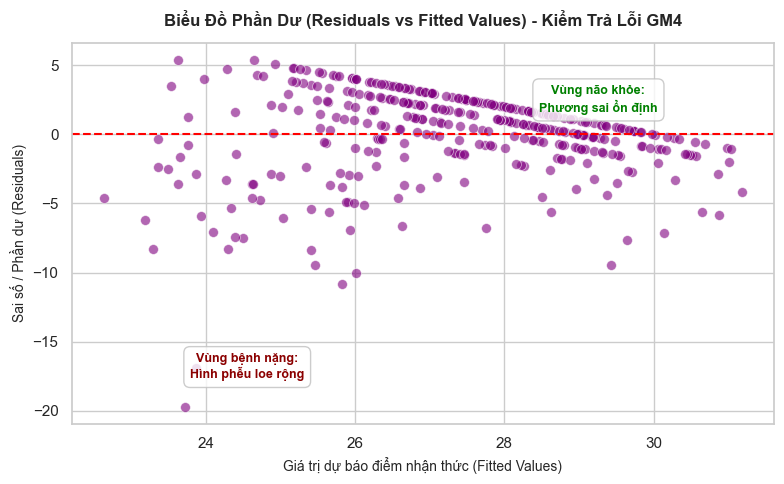

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

df = pd.read_csv('data/oasis_longitudinal.csv').dropna(subset=['MMSE', 'nWBV', 'Age', 'EDUC'])

X = df[['nWBV', 'Age', 'EDUC']]
X = sm.add_constant(X)
y = df['MMSE']

ols_model = sm.OLS(y, X)
baseline_results = ols_model.fit()

fitted_values = baseline_results.fittedvalues
residuals = baseline_results.resid

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6, color='purple', s=50, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

ax.set_title('Biểu Đồ Phần Dư (Residuals vs Fitted Values) - Kiểm Trả Lỗi GM4', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Giá trị dự báo điểm nhận thức (Fitted Values)', fontsize=10)
ax.set_ylabel('Sai số / Phần dư (Residuals)', fontsize=10)

ax.text(0.75, 0.85, 'Vùng não khỏe:\nPhương sai ổn định',
        color='green', fontsize=9, fontweight='bold',
        horizontalalignment='center', verticalalignment='center',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='silver', boxstyle='round,pad=0.5'))

ax.text(0.25, 0.15, 'Vùng bệnh nặng:\nHình phễu loe rộng',
        color='darkred', fontsize=9, fontweight='bold',
        horizontalalignment='center', verticalalignment='center',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='silver', boxstyle='round,pad=0.5'))

plt.tight_layout()

robust_results = ols_model.fit(cov_type='HC3')

print("\n=== KẾT QUẢ MÔ HÌNH HỒI QUY HIỆU CHỈNH ROBUST STANDARD ERRORS (HC3) ===")
print(robust_results.summary())


### 2.4. Kiểm tra Xung đột Dữ liệu (Data Conflicts)
Vì đây là bộ dữ liệu theo dõi dọc - một bệnh nhân được đo nhiều lần qua các năm, chúng tôi tiến hành kiểm tra hai dạng xung đột logic nghiêm trọng:
1. **Xung đột thuộc tính bất biến :** Các thuộc tính cố định suốt đời của một người như Giới tính (`M/F`), Tay thuận (`Hand`), Học vấn (`EDUC`) có bị thay đổi giữa các `Visit` của cùng một `Subject ID` hay không?
    * *Kết quả:* Không có xung đột. Giới tính và tay thuận nhất quán 100%. Số năm học vấn giữ nguyên (cho thấy các đối tượng đều đã hoàn thành lộ trình học tập từ trước khi tham gia nghiên cứu).
2. **Xung đột tiến trình thời gian :** Tuổi tác (`Age`) và Số ngày trễ (`MR Delay`) có tăng tiến một cách logic theo số thứ tự lần khám (`Visit`) hay không?
    * *Kết quả:* Hợp lệ. `Visit` càng lớn thì `Age` và `MR Delay` đều tăng tiến tịnh tiến một cách tuyến tính, không xuất hiện lỗi logic đảo ngược thời gian.

=> **Kết luận chung về chất lượng dữ liệu:** Bộ dữ liệu OASIS-2 có cấu trúc logic rất chặt chẽ, không vướng xung đột hệ thống hay trùng lặp. Vấn đề cốt lõi cần can thiệp xử lý duy nhất là hiện tượng khuyết thiếu ở cột `SES` và `MMSE`, cùng với việc chuẩn bị phương án đối phó hiện tượng phương sai thay đổi khi mô hình hóa.
### 2.5. Phân tích mối quan hệ giữa các biến
Dựa trên ma trận tương quan hệ số Pearson ($r$) được trích xuất từ tập dữ liệu OASIS-2, các mối liên kết tuyến tính giữa các đặc trưng được phân rã thành các luận điểm cốt lõi sau:

#### 2.5.1. Mối tương quan với Biến mục tiêu (`MMSE`)
* **`nWBV` và `MMSE` ($r = 0.34$):** Đây là biến có mối tương quan thuận mạnh nhất với biến mục tiêu. Kết quả này minh chứng thực nghiệm cho giả thuyết y khoa: thể tích toàn bộ não được chuẩn hóa càng cao (não ít bị teo) thì năng lực nhận thức lâm sàng của bệnh nhân càng tốt.
* **`EDUC` và `MMSE` ($r = 0.19$):** Tương quan thuận vừa phải. Số năm học vấn cao đóng vai trò như một màng đệm dự trữ nhận thức (Cognitive Reserve), hỗ trợ làm chậm tốc độ suy giảm trí tuệ ở người cao tuổi.
* **`SES` và `MMSE` ($r = -0.15$):** Tương quan nghịch nhẹ. Vì chỉ số Kinh tế - Xã hội quy ước ngược (1 là cao nhất, 5 là thấp nhất), hệ số âm chỉ ra rằng những người có vị thế kinh tế xã hội cao hơn (chỉ số SES nhỏ hơn) thường sở hữu mức độ minh mẫn tốt hơn.

#### 2.5.2. Bằng chứng thực nghiệm về Đa cộng tuyến hoàn hảo (`eTIV` và `ASF`)
* **`eTIV` và `ASF` ($r = -0.98$):** Xuất hiện mối tương quan nghịch tuyệt đối (tiệm cận mức $-1.00$).
* **Hệ quả hệ thống:** Hai đặc trưng này bản chất chứa đựng thông tin trùng lặp hoàn toàn do cơ chế tính toán hình học tuyến tính nghịch đảo của máy quét MRI. Đây là bằng chứng toán học đanh thép bảo chứng cho quyết định **loại bỏ biến `ASF`** ngay từ bước tiền xử lý nhằm triệt tiêu hoàn toàn rủi ro sụp đổ ma trận nghịch đảo do lỗi **Đa cộng tuyến hoàn hảo** khi cấu hình mô hình OLS.

#### 2.5.3. Các mối liên kết Nhân khẩu học và Hình thái học
* **`EDUC` và `SES` ($r = -0.44$):** Tương quan nghịch khá mạnh. Số năm đi học càng nhiều tỷ lệ nghịch với số thang đo `SES` (tương ứng với vị thế kinh tế xã hội càng cao), phản ánh chính xác logic phân lớp xã hội thực tế.
* **`Is_Male` và `eTIV` ($r = 0.58$):** Tương quan thuận mạnh, chỉ ra đặc trưng hình thái học tự nhiên: bệnh nhân Nam (`Is_Male = 1`) có xu hướng sở hữu tổng thể tích hộp sọ (`eTIV`) lớn hơn đáng kể so với Nữ. Tuy nhiên, biến giới tính không cho thấy mối tương quan tuyến tính trực tiếp nào với điểm nhận thức `MMSE` ($r = -0.03$).

=== MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ===
          MMSE   nWBV   eTIV    ASF    Age   EDUC    SES  Is_Male
MMSE     1.000  0.341 -0.019  0.028  0.056  0.184 -0.149   -0.160
nWBV     0.341  1.000 -0.207  0.211 -0.526 -0.020  0.090   -0.242
eTIV    -0.019 -0.207  1.000 -0.989  0.040  0.268 -0.262    0.571
ASF      0.028  0.211 -0.989  1.000 -0.032 -0.252  0.256   -0.561
Age      0.056 -0.526  0.040 -0.032  1.000 -0.025 -0.047   -0.028
EDUC     0.184 -0.020  0.268 -0.252 -0.025  1.000 -0.723    0.090
SES     -0.149  0.090 -0.262  0.256 -0.047 -0.723  1.000   -0.046
Is_Male -0.160 -0.242  0.571 -0.561 -0.028  0.090 -0.046    1.000


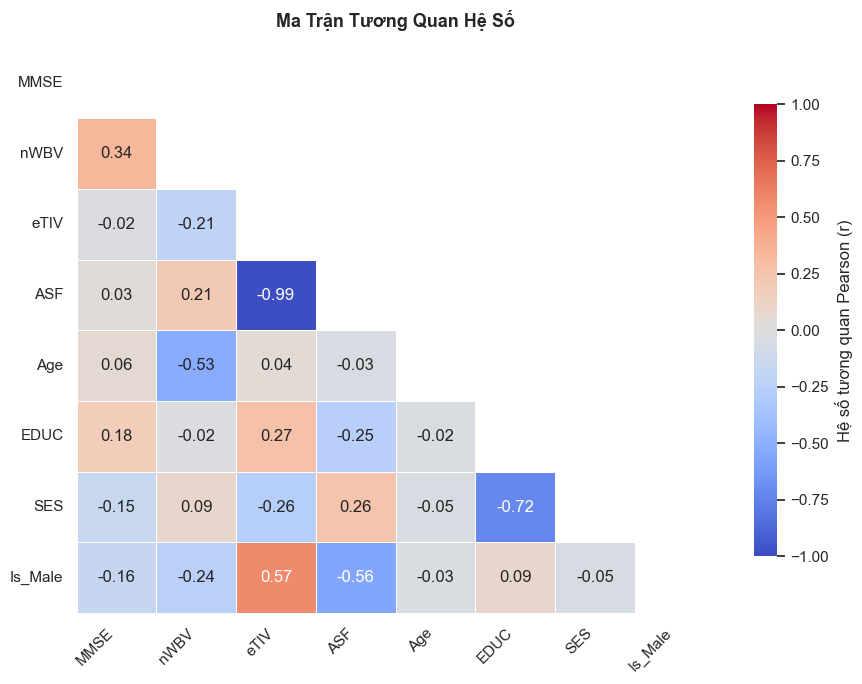

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/oasis_longitudinal.csv')

df['Is_Male'] = df['M/F'].map({'M': 1, 'F': 0})

features_to_corr = ['MMSE', 'nWBV', 'eTIV', 'ASF', 'Age', 'EDUC', 'SES', 'Is_Male']
df_numeric = df[features_to_corr].dropna()

corr_matrix = df_numeric.corr(method='pearson')

print("=== MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ===")
print(corr_matrix.round(3))

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmax=1.0, vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Hệ số tương quan Pearson (r)"},
    ax=ax
)

ax.set_title('Ma Trận Tương Quan Hệ Số', fontsize=13, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

### 2.6. Phân phối biến và thống kê mô tả
#### 2.6.1. Thống kê mô tả tổng thể các biến số (Trước khi lọc)

Để có cái nhìn toàn diện về đặc trưng phân phối, xu hướng tập trung và độ phân tán của dữ liệu gốc trước khi tiến hành quy trình sàng lọc đặc trưng và xử lý dữ liệu khuyết thiếu, nghiên cứu thực hiện tính toán các chỉ số thống kê mô tả đối với toàn bộ 11 biến số có nghĩa trong tập dữ liệu OASIS-2.

| STT | Ký hiệu biến | Giá trị trung bình (Mean) | Độ lệch chuẩn (Std. Dev) | Giá trị nhỏ nhất (Min) | Trung vị (Median) | Giá trị lớn nhất (Max) | Số lượng khuyết thiếu (NaN) |
| :---: | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | `Group` | *N/A (Định danh)* | *N/A* | *N/A* | *N/A* | *N/A* | 0 |
| 2 | `Visit` | 1.88 | 0.92 | 1.00 | 2.00 | 5.00 | 0 |
| 3 | `MR Delay` | 595.10 | 443.19 | 0.00 | 552.00 | 2639.00 | 0 |
| 4 | `Age` | 77.01 | 7.64 | 60.00 | 77.00 | 98.00 | 0 |
| 5 | `EDUC` | 14.60 | 2.88 | 6.00 | 15.00 | 23.00 | 0 |
| 6 | `SES` | 2.46 | 1.13 | 1.00 | 2.00 | 5.00 | 19 |
| 7 | `MMSE` | 27.34 | 3.68 | 4.00 | 29.00 | 30.00 | 2 |
| 8 | `CDR` | 0.29 | 0.37 | 0.00 | 0.00 | 2.00 | 0 |
| 9 | `eTIV` | 1488.12 | 176.13 | 1106.00 | 1475.00 | 2004.00 | 0 |
| 10 | `nWBV` | 0.73 | 0.04 | 0.64 | 0.73 | 0.84 | 0.00 |
| 11 | `ASF` | 1.20 | 0.14 | 0.88 | 1.19 | 1.59 | 0 |

*Ghi chú: Đối với các biến phân loại định danh như `Group`, các chỉ số toán học dạng số (Mean, Std,...) không có ý nghĩa nên được ký hiệu là N/A.*

---

#### 2.6.2. Phân tích chi tiết cấu trúc phân phối các nhóm biến

Dựa trên bảng thống kê mô tả tổng hợp và hệ thống đồ thị tần suất, cấu trúc nội tại của các biến trước khi lọc được phân rã thành 3 nhóm đặc trưng chính:

#### 1. Nhóm biến lâm sàng và bệnh lý (`Group`, `MMSE`, `CDR`)
* **`Group`:** Biến phân loại định danh chia bệnh nhân thành 3 nhóm (Demented - Sa sút trí tuệ, Nondemented - Khỏe mạnh, và Converted - Chuyển biến bệnh trong quá trình theo dõi). Đây là biến phân lớp nền tảng phản ánh trạng thái thực tế của mẫu.
* **`MMSE` (Điểm nhận thức):** Đạt trung bình $27.34$ điểm nhưng có trung vị rất cao ($29.00$ điểm), bộc lộ hiện tượng **lệch trái (Left-skewed)** mạnh do thang đo bị chặn trần ở mức 30 điểm. Xuất hiện 2 mẫu khuyết thiếu cần được loại bỏ trước khi chạy hồi quy.
* **`CDR` (Chỉ số phân giai đoạn lâm sàng):** Có giá trị trung bình thấp ($0.29$) và trung vị bằng $0.00$. Điều này cho thấy phần lớn tập mẫu quan sát nằm ở trạng thái bình thường hoặc chớm suy giảm nhận thức nhẹ ($CDR = 0.5$), nhóm bệnh nhân chuyển biến nặng ($CDR \ge 1.0$) chiếm tỷ trọng nhỏ.

#### 2. Nhóm biến hình thái học não bộ (`eTIV`, `nWBV`, `ASF`)
* **`nWBV` (Tỷ lệ thể tích chất não):** Tuân theo **phân phối chuẩn (Normal Distribution)** lý tưởng với giá trị trung bình và trung vị hội tụ tại mốc $0.73$. Biên độ dao động hẹp ($0.64$ đến $0.84$) phản ánh tiến trình teo não diễn ra tịnh tiến ổn định theo quy luật sinh học.
* **`eTIV` và `ASF`:** Thể tích sọ `eTIV` có độ lệch chuẩn rất lớn ($176.13$), dao động mạnh từ $1106$ đến $2004$ $mm^3$ tùy thuộc vào thể trạng từng người. Ngược lại, hệ số co giãn `ASF` có giá trị trung bình rất nhỏ ($1.20$). Sự đối nghịch và tương quan chặt chẽ giữa hai biến này ($r = -0.98$) là dấu hiệu cảnh báo lỗi đa cộng tuyến nếu giữ lại cả hai.
#### 3. Nhóm biến nhân khẩu học và tiến trình (`Age`, `EDUC`, `SES`, `Visit`, `MR Delay`)
* **`Age` & `EDUC`:** Tập mẫu tập trung vào nhóm người cao tuổi (trung bình $77.01$ tuổi). Trình độ học vấn tương đối cao với trung bình $14.60$ năm đi học, phân phối xuất hiện các đỉnh nhọn tại mốc tốt nghiệp phổ thông (12 năm) và đại học (16 năm).
* **`SES` (Vị thế xã hội):** Ghi nhận **19 dòng khuyết thiếu (NaN)** - đây là biến có tỷ lệ trống cao nhất trong tập dữ liệu, đặt ra yêu cầu phải áp dụng kỹ thuật gán khuyết thiếu nâng cao (Group-by Median) để không làm mất mát thông tin khi đưa vào mô hình.
* **`Visit` & `MR Delay`:** Số lần khám trung bình là $1.88$ lần. Biến `MR Delay` (thời gian trễ giữa các lần chụp) có độ lệch chuẩn cực lớn ($443.19$ ngày), trải dài từ $0$ ngày (lần khám đầu tiên) cho đến tối đa $2639$ ngày, cho thấy độ giãn cách dòng thời gian của dữ liệu dọc (Longitudinal) là rất rộng.


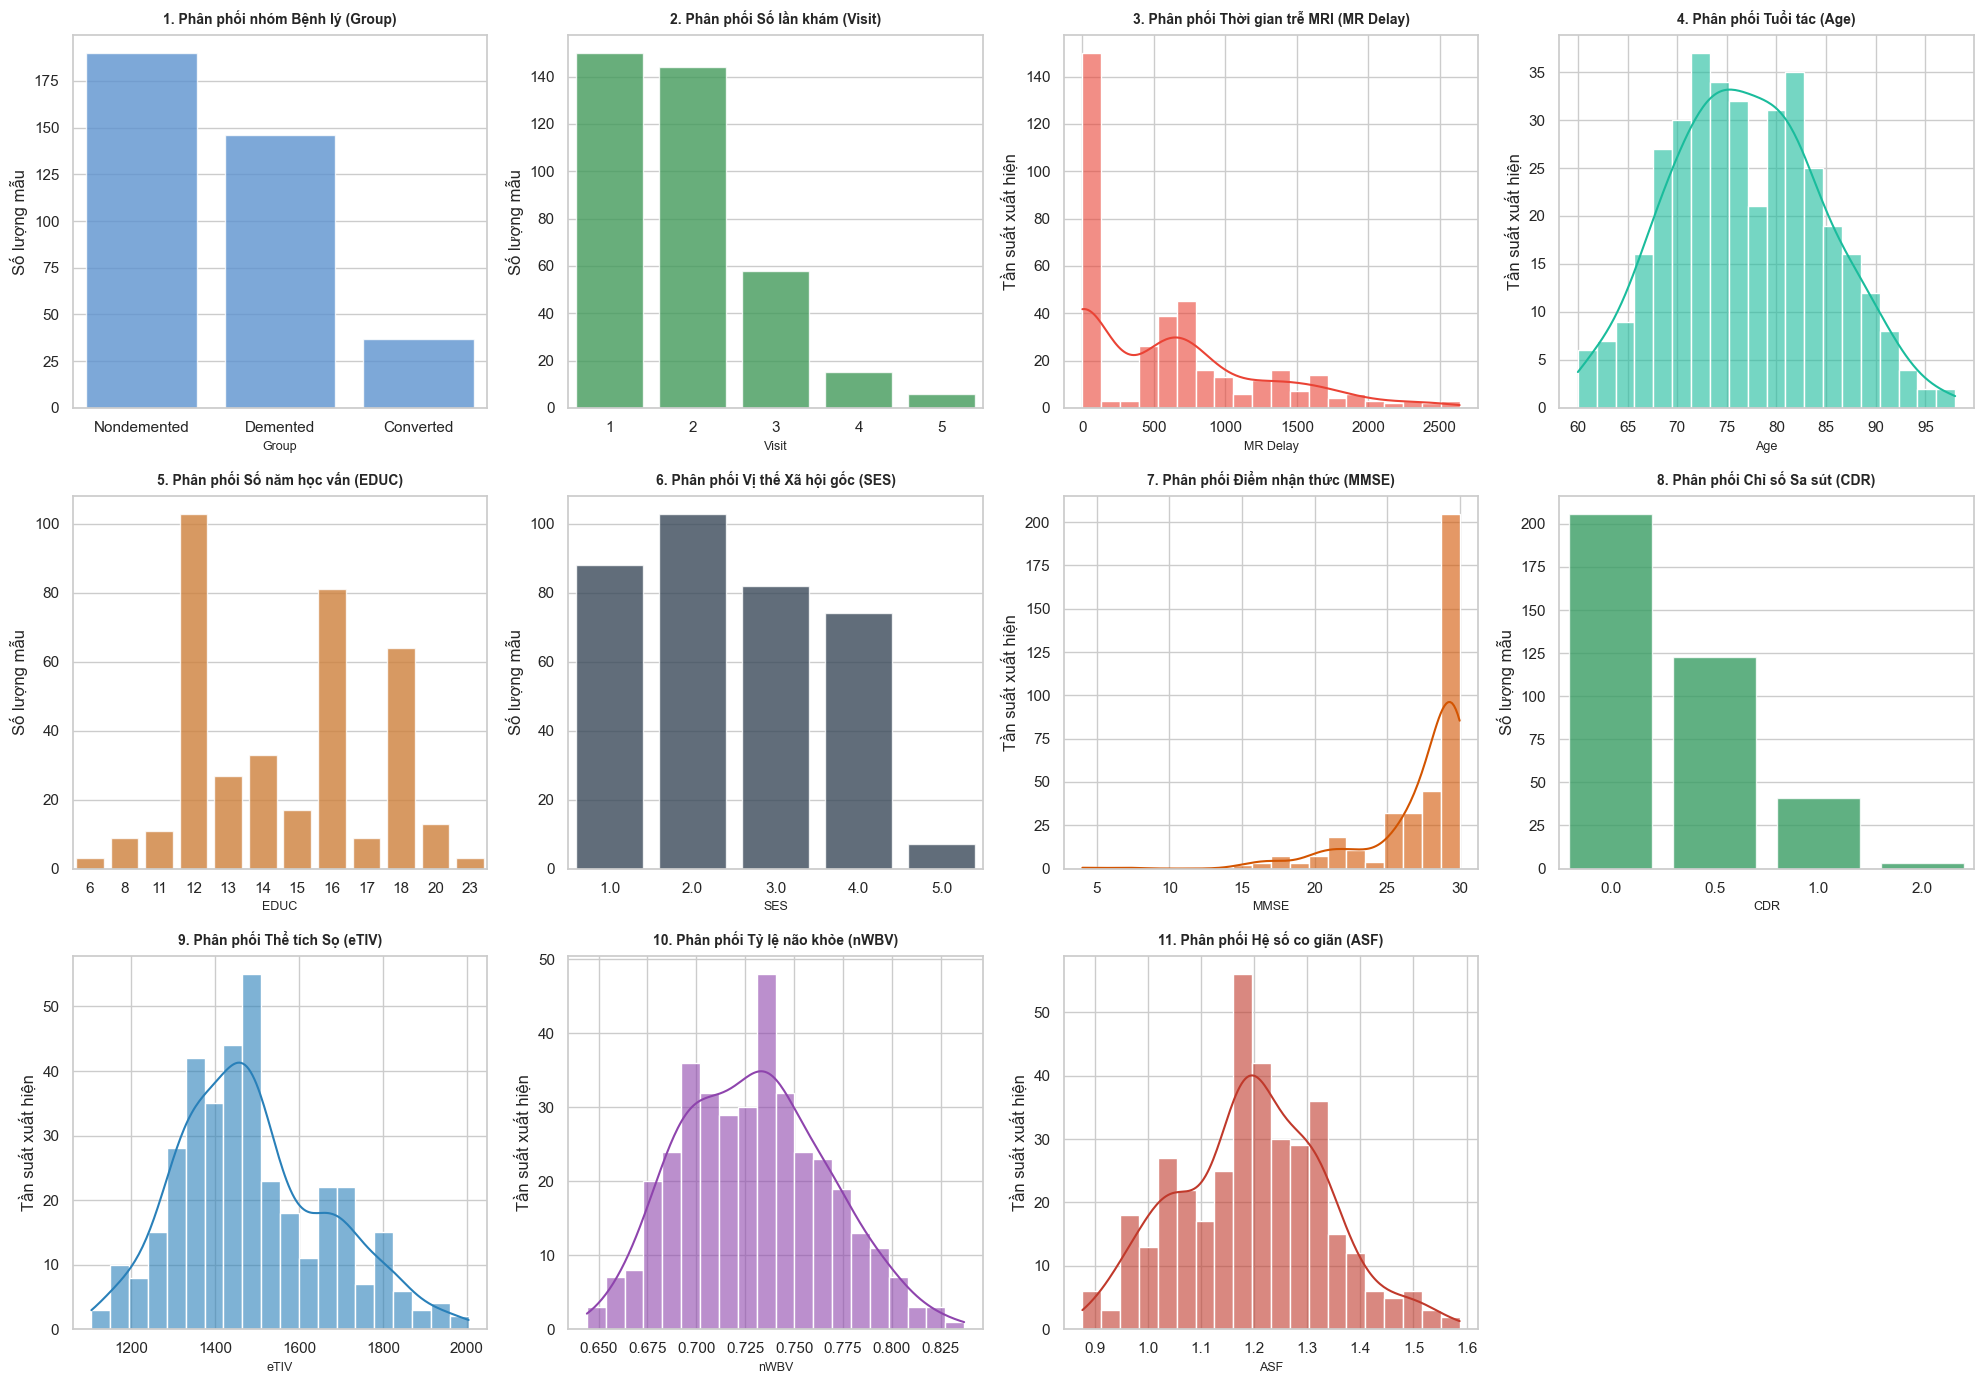

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/oasis_longitudinal.csv')

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

columns_config = [
    {'col': 'Group', 'title': '1. Phân phối nhóm Bệnh lý (Group)', 'type': 'categorical', 'color': '#4a90e2'},
    {'col': 'Visit', 'title': '2. Phân phối Số lần khám (Visit)', 'type': 'discrete', 'color': '#34a853'},
    {'col': 'MR Delay', 'title': '3. Phân phối Thời gian trễ MRI (MR Delay)', 'type': 'continuous', 'color': '#ea4335'},
    {'col': 'Age', 'title': '4. Phân phối Tuổi tác (Age)', 'type': 'continuous', 'color': '#1abc9c'},
    {'col': 'EDUC', 'title': '5. Phân phối Số năm học vấn (EDUC)', 'type': 'discrete', 'color': '#e67e22'},
    {'col': 'SES', 'title': '6. Phân phối Vị thế Xã hội gốc (SES)', 'type': 'discrete', 'color': '#34495e'},
    {'col': 'MMSE', 'title': '7. Phân phối Điểm nhận thức (MMSE)', 'type': 'continuous', 'color': '#d35400'},
    {'col': 'CDR', 'title': '8. Phân phối Chỉ số Sa sút (CDR)', 'type': 'discrete', 'color': '#27ae60'},
    {'col': 'eTIV', 'title': '9. Phân phối Thể tích Sọ (eTIV)', 'type': 'continuous', 'color': '#2980b9'},
    {'col': 'nWBV', 'title': '10. Phân phối Tỷ lệ não khỏe (nWBV)', 'type': 'continuous', 'color': '#8e44ad'},
    {'col': 'ASF', 'title': '11. Phân phối Hệ số co giãn (ASF)', 'type': 'continuous', 'color': '#c0392b'}
]

for i, config in enumerate(columns_config):
    ax = axes[i]
    col_name = config['col']

    if col_name in df.columns:
        if config['type'] == 'categorical':
            order = df[col_name].value_counts().index
            sns.countplot(data=df, x=col_name, order=order, ax=ax, color=config['color'], alpha=0.8)
            ax.set_ylabel('Số lượng mẫu')

        elif config['type'] == 'discrete':
            sns.countplot(data=df, x=col_name, ax=ax, color=config['color'], alpha=0.8)
            ax.set_ylabel('Số lượng mẫu')

        elif config['type'] == 'continuous':
            sns.histplot(data=df, x=col_name, kde=True, ax=ax, color=config['color'], bins=20, alpha=0.6)
            ax.set_ylabel('Tần suất xuất hiện')

        ax.set_title(config['title'], fontsize=10, fontweight='bold', pad=8)
        ax.set_xlabel(col_name, fontsize=9)
    else:
        ax.text(0.5, 0.5, f"Không tìm thấy\ncột '{col_name}'", ha='center', va='center', color='gray')

fig.delaxes(axes[11])

plt.tight_layout()


#### 2.6.3. Boxplots – Trực quan hóa phân phối và điểm bất thường

Bên cạnh histogram, **boxplot** là công cụ bổ sung không thể thiếu trong EDA: mỗi hộp thể hiện Q1, median, Q3 và whisker (1.5×IQR), trong khi các điểm nằm ngoài whisker là **ứng viên outlier trực quan**.

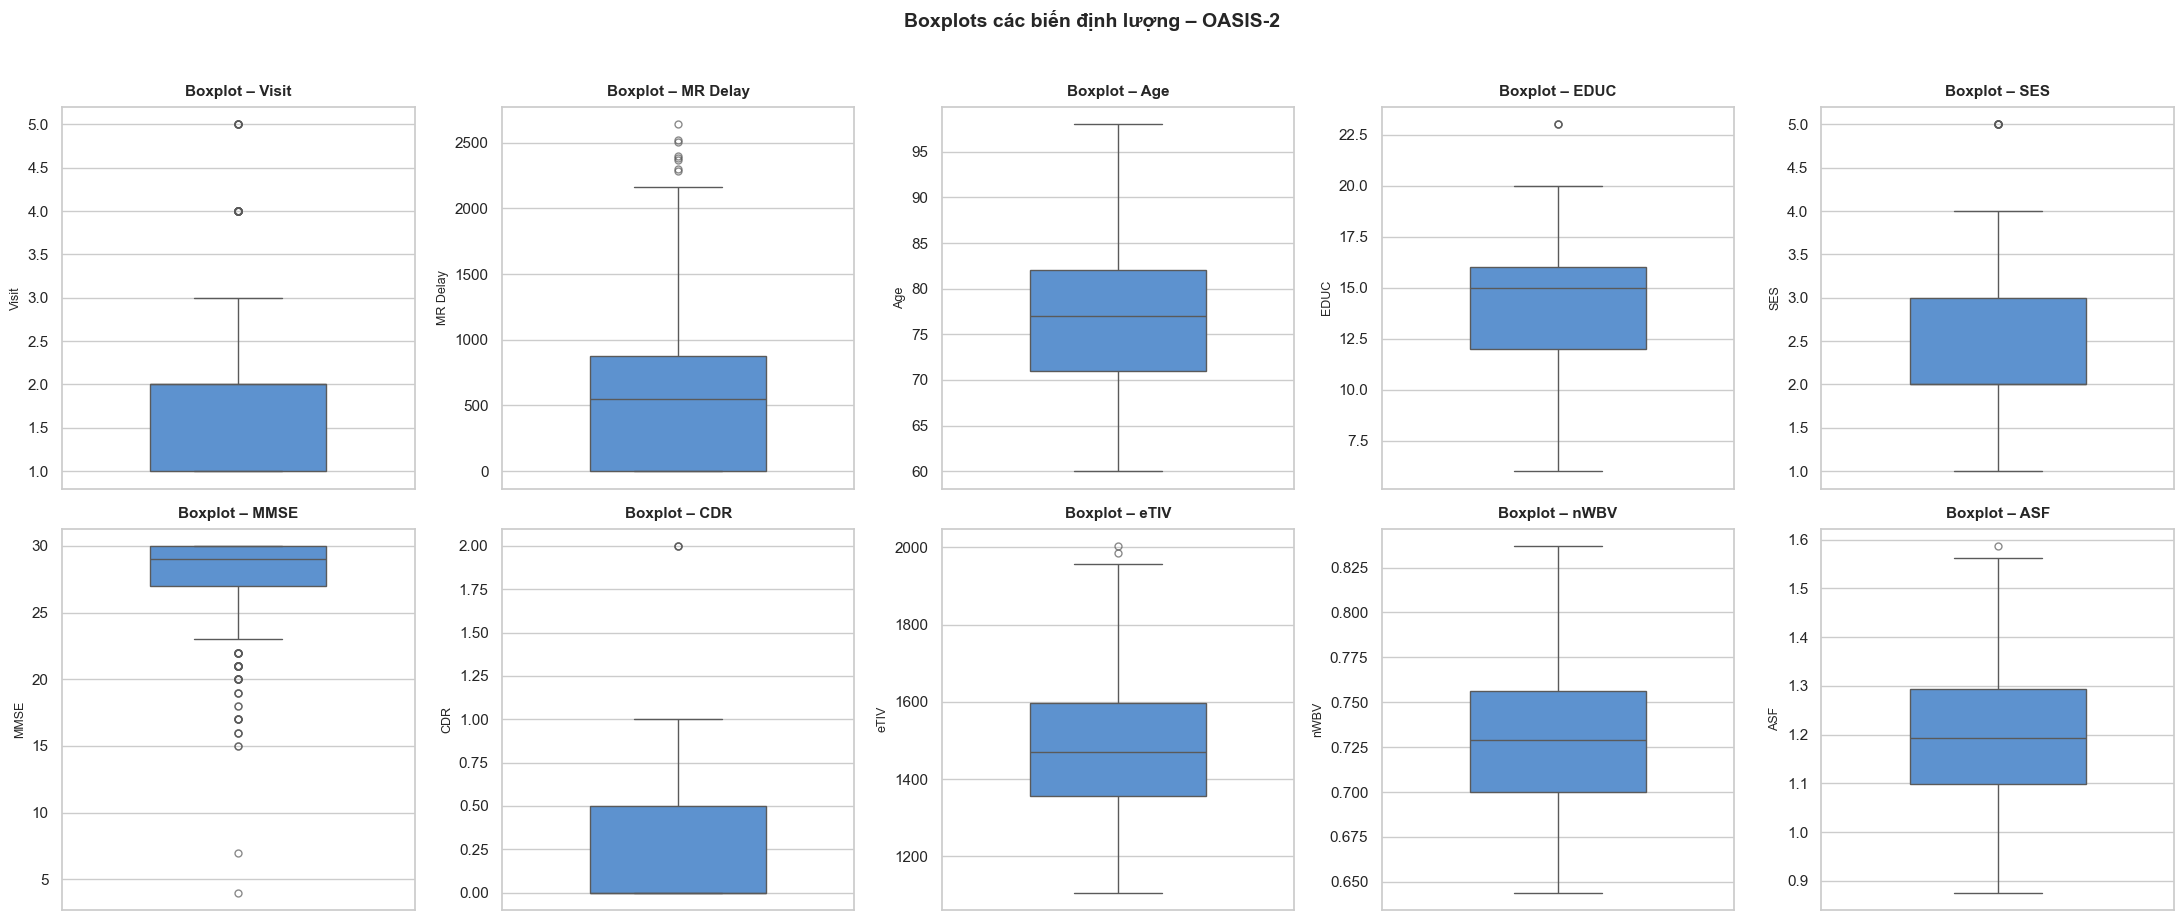

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/oasis_longitudinal.csv')

numerical_cols = ['Visit', 'MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(
        data=df, y=col, ax=ax,
        color='#4a90e2', width=0.5,
        flierprops=dict(marker='o', color='crimson', markersize=5, alpha=0.7)
    )
    ax.set_title(f'Boxplot – {col}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=9)

plt.suptitle('Boxplots các biến định lượng – OASIS-2', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### 2.6.4. Phát hiện Outliers bằng phương pháp toán học (IQR và Z-score)

Hai phương pháp định lượng được áp dụng song song để xác định chính xác số lượng và tỷ lệ outlier cho từng biến:

- **IQR Method:** Một điểm được coi là outlier nếu nằm ngoài khoảng $[Q_1 - 1.5 \times IQR,\ Q_3 + 1.5 \times IQR]$ với $IQR = Q_3 - Q_1$.
- **Z-score Method:** Một điểm được coi là outlier nếu $|Z| = \left|\dfrac{x_i - \bar{x}}{\sigma}\right| > 3$ (tức là cách trung bình hơn 3 độ lệch chuẩn).

KẾT QUẢ PHÁT HIỆN OUTLIERS – IQR vs Z-SCORE
                Q1        Q3      IQR  Ngưỡng dưới (IQR)  Ngưỡng trên (IQR)  Outliers (IQR)  % (IQR)  Outliers (Z>3)  % (Z>3)
Biến                                                                                                                         
Visit        1.000     2.000    1.000             -0.500              3.500              21     5.63               6     1.61
MR Delay     0.000   873.000  873.000          -1309.500           2182.500               8     2.14               3     0.80
Age         71.000    82.000   11.000             54.500             98.500               0     0.00               0     0.00
EDUC        12.000    16.000    4.000              6.000             22.000               3     0.80               0     0.00
SES          2.000     3.000    1.000              0.500              4.500               7     1.98               0     0.00
MMSE        27.000    30.000    3.000             22.500             34.50

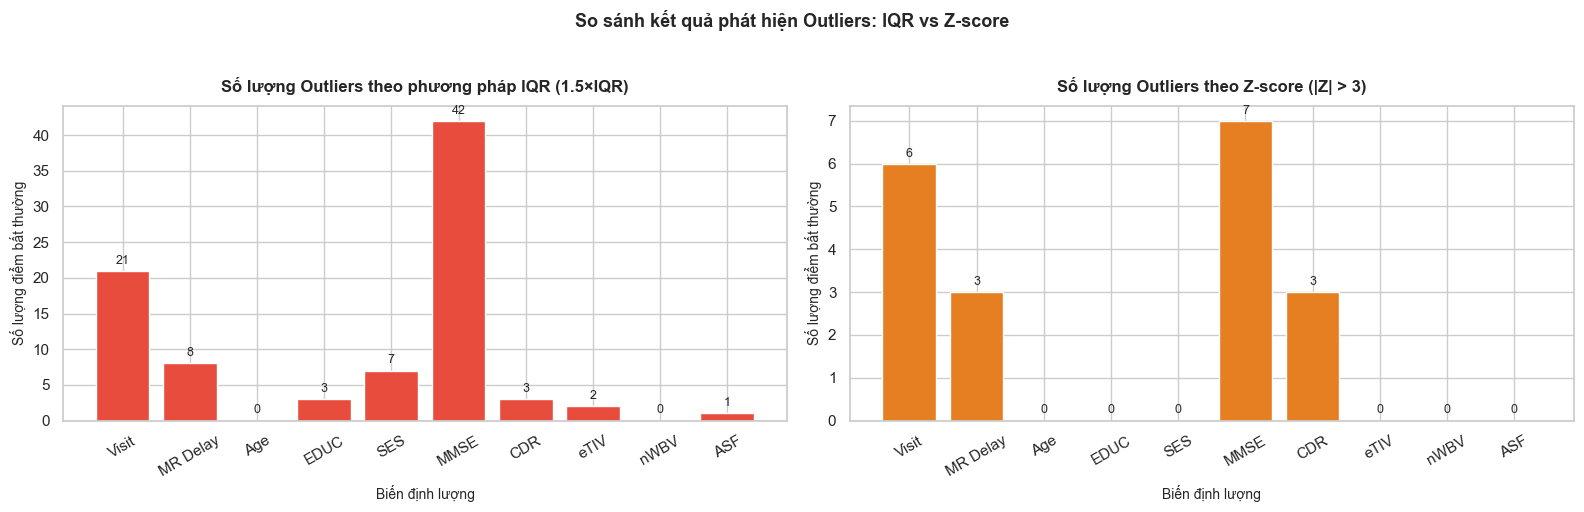

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/oasis_longitudinal.csv')

numerical_cols = ['Visit', 'MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
n_total = len(df)

results = []

for col in numerical_cols:
    series = df[col].dropna()
    n_valid = len(series)

    # ── IQR method ────────────────────────────────────────────────────────────
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    outliers_iqr = series[(series < lower_iqr) | (series > upper_iqr)]
    n_iqr = len(outliers_iqr)

    # ── Z-score method ────────────────────────────────────────────────────────
    z_scores = np.abs((series - series.mean()) / series.std())
    outliers_z = series[z_scores > 3]
    n_z = len(outliers_z)

    results.append({
        'Biến': col,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Ngưỡng dưới (IQR)': round(lower_iqr, 3),
        'Ngưỡng trên (IQR)': round(upper_iqr, 3),
        'Outliers (IQR)': n_iqr,
        '% (IQR)': round(n_iqr / n_valid * 100, 2),
        'Outliers (Z>3)': n_z,
        '% (Z>3)': round(n_z / n_valid * 100, 2),
    })

df_outliers = pd.DataFrame(results).set_index('Biến')

print("=" * 110)
print("KẾT QUẢ PHÁT HIỆN OUTLIERS – IQR vs Z-SCORE")
print("=" * 110)
print(df_outliers.to_string())
print()

# ── Summary ───────────────────────────────────────────────────────────────────
print("TÓM TẮT:")
for _, row in df_outliers.iterrows():
    if row['Outliers (IQR)'] > 0 or row['Outliers (Z>3)'] > 0:
        print(f"  • {_:<10} | IQR: {int(row['Outliers (IQR)']):>3} điểm ({row['% (IQR)']:>5.2f}%)"
              f"  |  Z-score: {int(row['Outliers (Z>3)']):>3} điểm ({row['% (Z>3)']:>5.2f}%)")

# ── Visual: bar chart số outliers theo IQR ────────────────────────────────────
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar – IQR
colors_iqr = ['#e74c3c' if v > 0 else '#95a5a6' for v in df_outliers['Outliers (IQR)']]
bars = axes[0].bar(df_outliers.index, df_outliers['Outliers (IQR)'], color=colors_iqr, edgecolor='white')
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=9)
axes[0].set_title('Số lượng Outliers theo phương pháp IQR (1.5×IQR)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Biến định lượng', fontsize=10)
axes[0].set_ylabel('Số lượng điểm bất thường', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

# Bar – Z-score
colors_z = ['#e67e22' if v > 0 else '#95a5a6' for v in df_outliers['Outliers (Z>3)']]
bars2 = axes[1].bar(df_outliers.index, df_outliers['Outliers (Z>3)'], color=colors_z, edgecolor='white')
axes[1].bar_label(bars2, fmt='%d', padding=3, fontsize=9)
axes[1].set_title('Số lượng Outliers theo Z-score (|Z| > 3)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Biến định lượng', fontsize=10)
axes[1].set_ylabel('Số lượng điểm bất thường', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('So sánh kết quả phát hiện Outliers: IQR vs Z-score', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Tiền xử lý Dữ liệu
### 3.1. Lựa chọn biến (Select Data)

Để xây dựng mô hình hồi quy tuyến tính OLS tối ưu nhằm dự đoán điểm nhận thức (`MMSE`), quy trình sàng lọc hệ thống đặc trưng được thực hiện dựa trên sự kết hợp giữa logic y sinh và bằng chứng thực nghiệm từ ma trận tương quan.

Mô hình cuối cùng tập trung vào 4 đặc trưng cốt lõi (1 biến mục tiêu và 4 biến độc lập):

* **`MMSE` (Biến mục tiêu - $Y$):** Thang đo trạng thái tâm thần tối thiểu, là chỉ số lâm sàng chuẩn hóa phản ánh trực tiếp mức độ suy giảm nhận thức hoặc sa sút trí tuệ của bệnh nhân.
* **`nWBV` (Biến độc lập - $X_1$):** Thể tích toàn bộ não được chuẩn hóa (Normalized Whole Brain Volume). Đây là biến hình thái học quan trọng nhất, đại diện cho mức độ teo não sinh học. Ma trận tương quan xác nhận `nWBV` có liên kết tuyến tính thuận mạnh nhất với `MMSE` ($r = 0.34$).
* **`EDUC` (Biến độc lập - $X_2$):** Số năm học vấn (Years of Education). Biến nhân khẩu học này đại diện cho "Dự trữ nhận thức" (Cognitive Reserve). Thực nghiệm cho thấy mối tương quan thuận ($r = 0.19$), trợ lực làm chậm tiến trình bộc lộ triệu chứng mất trí nhớ.
* **`Age` (Biến độc lập - $X_3$):** Tuổi tác của bệnh nhân. Lão hóa là yếu tố nguy cơ tự nhiên hàng đầu gắn liền với sự suy giảm chức năng thần kinh.
* **`SES` (Biến độc lập - $X_4$):** Chỉ số kinh tế xã hội. Alzheimer không chỉ bị thao túng bởi các yếu tố sinh học thuần túy (`nWBV`, `Age`) mà còn bị chi phối mạnh mẽ bởi bối cảnh kinh tế - xã hội. Người có chỉ số `SES` cao (tương ứng với vị thế xã hội tốt hơn) thường có điều kiện tiếp cận dịch vụ chăm sóc y tế chất lượng cao, chế độ dinh dưỡng tối ưu và lối sống lành mạnh hơn. Đây là những nhân tố gián tiếp thiết lập màng đệm bảo vệ hệ thần kinh, giúp kiểm soát tốc độ suy giảm điểm số `MMSE`.

Để tối ưu hóa bậc tự do và bảo vệ mô hình khỏi các hiện tượng nhiễu hay đa cộng tuyến nghiêm trọng, 6 thuộc tính dưới đây đã chủ động bị loại bỏ:

* **`Hand` (Tay thuận):** * *Lý do:* Toàn bộ $100\%$ mẫu quan sát trong dữ liệu đều ghi nhận bệnh nhân thuận tay phải (`R`). Biến này có phương sai bằng 0 (biến hằng số), hoàn toàn không có giá trị phân hóa thống kê.
* **`ASF` (Hệ số co giãn thể tích sọ):** * *Lý do:* Tương quan nghịch tuyệt đối với `eTIV` ($r = -0.98$). Nếu giữ lại sẽ gây ra lỗi **Đa cộng tuyến hoàn hảo (Perfect Multicollinearity)**, làm sụp đổ thuật toán đảo ma trận của OLS.
* **`eTIV` (Tổng thể tích hộp sọ):** * *Lý do:* Đo lường thể tích xương sọ cố định và độc lập tuyến tính với điểm nhận thức `MMSE` ($r = 0.02$). Giữ lại biến này cạnh `nWBV` không đóng góp thêm giá trị giải thích mà làm nhiễu mô hình.
* **`M/F` (Giới tính bệnh nhân):** * *Lý do:* Thực nghiệm cho thấy giới tính không có mối tương quan tuyến tính trực tiếp nào với năng lực nhận thức lâm sàng `MMSE` ($r = -0.03$). Yếu tố giới tính chỉ ảnh hưởng đến kích thước sọ tự nhiên (`eTIV`).
* **`Group` (Nhóm phân loại bệnh lý):** * *Lý do:* Đây là kết luận trạng thái đầu ra (Đã sa sút trí tuệ/Khỏe mạnh). Việc đưa `Group` vào mô hình để dự đoán `MMSE` sẽ gây ra hiện tượng **Nhiễm độc thông tin (Data Leakage)**, vì bản chất điểm `MMSE` là một trong những tiêu chí lâm sàng chính được dùng để phân loại nhóm bệnh lý này.
* **`MR Delay` & `Visit` (Tiến trình thời gian chụp):** * *Lý do:* `Visit` (Số thứ tự lần khám) và `MR Delay` (Số ngày giãn cách giữa các lần chụp) là các biến định danh dòng thời gian của dữ liệu dọc. Chúng không can thiệp trực tiếp vào cấu trúc sinh học hay năng lực tư duy tại thời điểm kiểm tra của bệnh nhân.

### 3.2. Làm sạch dữ liệu (Clean Data)
#### 3.2.1 Xử lý missing value
Trước khi tiến hành phân tích và xây dựng mô hình hồi quy OLS, nghiên cứu tiến hành rà soát toàn diện mức độ toàn vẹn của dữ liệu đầu vào. Kết quả kiểm tra ghi nhận thuộc tính Vị thế Kinh tế - Xã hội (`SES`) là biến số vướng tỷ lệ khuyết thiếu cao nhất trong bộ dữ liệu gốc OASIS-2.

Cụ thể, trên tổng số $n = 373$ mẫu quan sát, biến `SES` bị khuyết thiếu **19 dòng**, tương đương với tỷ lệ **5.09%**. Theo các nghiên cứu chuẩn mực về xử lý dữ liệu (Hair et al., 2010), nếu tỷ lệ dữ liệu khuyết thiếu nằm trong ngưỡng an toàn dưới 10%, việc áp dụng các kỹ thuật gán dữ liệu thay thế (Imputation) là hoàn toàn hợp lệ về mặt toán học. Hành động này giúp bảo toàn kích thước mẫu, tránh hiện tượng mất mát thông tin nghiêm trọng so với phương pháp loại bỏ dòng truyền thống.

In [30]:
import pandas as pd

df = pd.read_csv('data/oasis_longitudinal.csv')

total_rows = len(df)
missing_count = df['SES'].isnull().sum()
missing_percentage = (missing_count / total_rows) * 100

print(f"Tổng số lượng mẫu quan sát trong dữ liệu: {total_rows}")
print(f"Số lượng mẫu bị khuyết thiếu tại biến SES: {missing_count}")
print(f"Tỷ lệ khuyết thiếu của biến SES: {missing_percentage:.2f}%")

Tổng số lượng mẫu quan sát trong dữ liệu: 373
Số lượng mẫu bị khuyết thiếu tại biến SES: 19
Tỷ lệ khuyết thiếu của biến SES: 5.09%


Để lựa chọn chiến lược xử lý tối ưu, nghiên cứu tiến hành phân tích bản chất toán học đằng sau các ô dữ liệu bị bỏ trống của biến `SES` dựa trên ba cơ chế kinh điển: MCAR, MAR và MNAR.

Qua phân tích ma trận tương quan hệ số Pearson, thuộc tính `SES` và Trình độ học vấn (`EDUC`) sở hữu một mối liên kết tuyến tính chặt chẽ ($r = -0.44$). Điều này chỉ ra rằng xác suất một bệnh nhân từ chối hoặc bỏ trống thông tin về Vị thế Kinh tế - Xã hội không diễn ra một cách vô tri, ngẫu nhiên hoàn toàn (không phải MCAR), mà bị chi phối trực tiếp bởi nền tảng giáo dục của chính họ. Những đối tượng có số năm đi học đặc thù thường có xu hướng bỏ trống khai báo vị thế xã hội.

Do đó, nghiên cứu khẳng định biến `SES` vướng hiện tượng **Khuyết thiếu ngẫu nhiên có điều kiện - MAR (Missing at Random)**. Vì giá trị khuyết thiếu của `SES` có thể giải thích và dự báo được thông qua biến mỏ neo `EDUC`, việc sử dụng chính đặc trưng `EDUC` để khôi phục dữ liệu cho `SES` là giải pháp hoàn toàn có cơ sở khoa học, giúp loại bỏ hiện tượng thiên lệch mẫu (Sample Bias) tốt so với việc xóa bỏ hoàn toàn các dòng dữ liệu.

In [31]:
import pandas as pd

df = pd.read_csv('data/oasis_longitudinal.csv')

educ_with_ses = df[df['SES'].notnull()]['EDUC'].mean()
educ_missing_ses = df[df['SES'].isnull()]['EDUC'].mean()

print(f"Số năm học vấn trung bình của nhóm CÓ điền SES: {educ_with_ses:.2f} năm")
print(f"Số năm học vấn trung bình của nhóm BỎ TRỐNG SES: {educ_missing_ses:.2f} năm")

Số năm học vấn trung bình của nhóm CÓ điền SES: 14.70 năm
Số năm học vấn trung bình của nhóm BỎ TRỐNG SES: 12.63 năm


Nhằm bảo toàn cấu trúc thứ bậc nguyên bản của thuộc tính `SES` và tận dụng mối liên kết tuyến tính chặt chẽ giữa học vấn và vị thế kinh tế, đồ án triển khai thuật toán gán khuyết thiếu có điều kiện. Thuật toán tiến hành phân rã tập dữ liệu thành các phân lớp dựa trên số năm học vấn (`EDUC`), tính toán giá trị trung vị (`Median`) đặc trưng cho từng phân lớp, sau đó lấp đầy các ô trống tương ứng bằng các giá trị đại diện này.

Để hiểu một cách đơn giản nhất, kỹ thuật này hoạt động giống như tìm manh mối để khôi phục thông tin bị ẩn giấu của biến Vị thế Kinh tế - Xã hội (`SES`), dựa trên một biến tương quan có sẵn là Trình độ học vấn (`EDUC`).

Cơ chế thực thi bao gồm 3 bước tự nhiên:

* **Bước 1 - Phân nhóm (Group-by):** Thuật toán không nhìn vào toàn bộ tập dữ liệu một cách chung chung. Nó tiến hành gom tất cả các bệnh nhân có cùng số năm đi học lại với nhau thành các nhóm độc lập (ví dụ: nhóm học 12 năm, nhóm học 16 năm, nhóm học 18 năm).
* **Bước 2 - Đối chiếu ngữ cảnh:** Khi một bệnh nhân bị khuyết thông tin `SES` nhưng hồ sơ ghi nhận có **16 năm đi học** (tốt nghiệp Đại học), thuật toán sẽ chạy thẳng vào nhóm "Những người học 16 năm" và đặt câu hỏi: *"Trong nhóm những người có cùng nền tảng học vấn này, đa số họ sở hữu mức vị thế xã hội bằng bao nhiêu?"*
* **Bước 3 - Lấy số số đông ở giữa (Median):** Máy tính sẽ xếp hàng tất cả các giá trị `SES` của những người trong nhóm đó từ thấp đến cao và chọn ra giá trị nằm ở **chính giữa hàng** để điền vào ô trống.

**Ưu điểm vượt trội của cách tiếp cận này:**
1. **Hợp lý với thực tế xã hội:** Tôn trọng quy luật người có học vấn cao thường sở hữu vị thế xã hội tốt hơn, tránh việc cào bằng một người học vị Tiến sĩ với một người chưa tốt nghiệp Phổ thông.
2. **Không tạo ra số thập p:** Vì chọn giá trị đứng giữa dãy (Trung vị), kết quả điền vào luôn là một số nguyên tròn trịa ($1, 2, 3, 4, 5$). Nếu dùng số trung bình (Mean), máy tính sẽ tính ra số thập phân (như $2.34$) – điều hoàn toàn vô nghĩa đối với một thang đo thứ bậc.
3. **Bảo toàn độ đa dạng:** Giúp dữ liệu sau khi sửa xong vẫn giữ được sự sinh động, phân hóa tự nhiên ban đầu chứ không bị dồn cục tại một giá trị duy nhất.

Để chứng minh tính hợp pháp và độ tin cậy của giải pháp này, đồ thị bên dưới đối chứng trước và sau khi gán đã được trích xuất.

Qua quan sát trực quan đồ thị, hình dáng hình học tổng thể của phân phối biến `SES` được giữ vững một cách lý tưởng. Tần suất phân bố vẫn tập trung đậm đặc tại nấc thang số 2 và số 1 (đại diện cho nhóm trung lưu và thượng lưu), trong khi dải phân bố ở các bậc thấp hơn (4 và 5) không hề bị đột biến hay lệch lạc cấu trúc. Kết quả này xác nhận giải pháp gán trung vị theo nhóm đã bổ khuyết thành công dữ liệu mà không hề tạo ra các hiện tượng nhiễu nhân tạo (Artifacts) hay làm thay đổi bản chất thông tin nền tảng của bộ dữ liệu gốc. Sau khâu xử lý này, kích thước mẫu sạch được bảo toàn tuyệt đối ở mức $n = 373$ phục vụ cho mô hình hồi quy OLS.

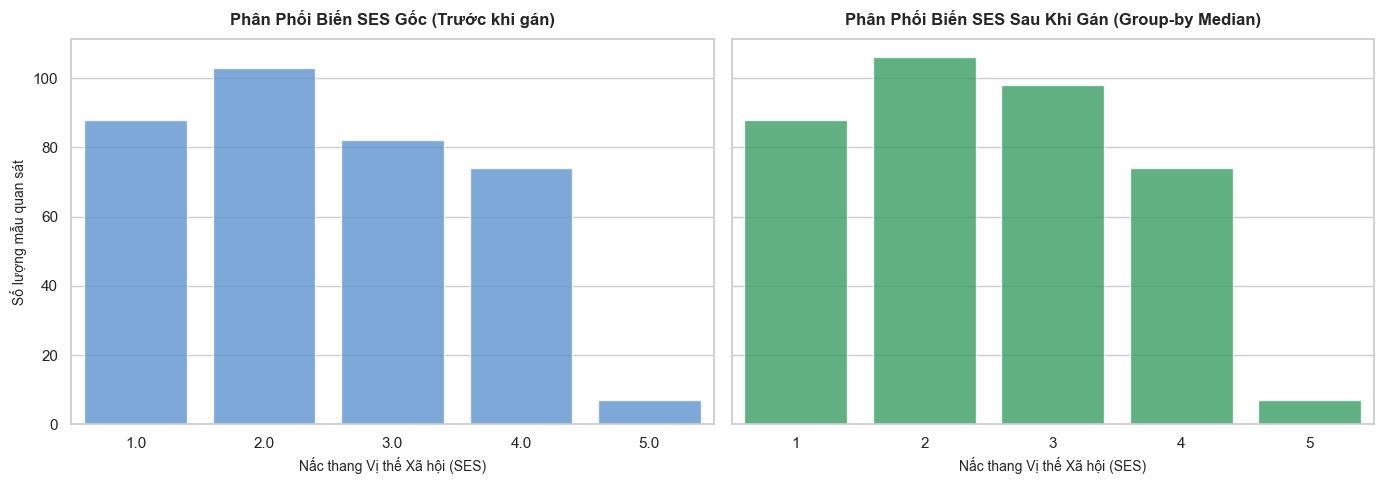

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/oasis_longitudinal.csv')

df_imputed = df.copy()

# Bước 1: Tính toán giá trị (Mode) tổng thể để dự phòng cho các nhóm quá đặc biệt
global_mode = df['SES'].mode()[0]

# Bước 2: Thực hiện gán khuyết thiếu theo trung vị (Median) của từng nhóm EDUC tương ứng
df_imputed['SES'] = df_imputed.groupby('EDUC')['SES'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else global_mode)
)

# Bước 3: Ép dữ liệu về kiểu số nguyên (Integer) để giữ nguyên cấu trúc phân loại thứ bậc
df_imputed['SES'] = df_imputed['SES'].astype(int)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Biểu đồ bên trái: Phân phối gốc (Trước khi gán - Bỏ qua các dòng trống)
sns.countplot(data=df.dropna(subset=['SES']), x='SES', ax=axes[0], color='#4a90e2', alpha=0.8)
axes[0].set_title('Phân Phối Biến SES Gốc (Trước khi gán)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Nấc thang Vị thế Xã hội (SES)', fontsize=10)
axes[0].set_ylabel('Số lượng mẫu quan sát', fontsize=10)

# Biểu đồ bên phải: Phân phối sau khi xử lý bằng thuật toán Group-by Median
sns.countplot(data=df_imputed, x='SES', ax=axes[1], color='#27ae60', alpha=0.8)
axes[1].set_title('Phân Phối Biến SES Sau Khi Gán (Group-by Median)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Nấc thang Vị thế Xã hội (SES)', fontsize=10)
axes[1].set_ylabel('')

plt.tight_layout()

Khác với biến độc lập `SES`, đối với **2 mẫu quan sát** bị khuyết thiếu ở biến phụ thuộc `MMSE`, đồ án quyết định áp dụng phương pháp **Loại bỏ dòng khuyết thiếu (Listwise Deletion)** thay vì tiến hành gán dữ liệu.

Cơ sở lý luận của quyết định này dựa trên hai nguyên tắc cốt lõi trong thống kê và hồi quy tuyến tính:

* **Tránh hiện tượng nhiễu nhân tạo cho biến mục tiêu:** `MMSE` là biến phụ thuộc ($Y$) – thực thể trực tiếp quy định tính chính xác của hàm hồi quy. Việc sử dụng bất kỳ thuật toán nào để gán một giá trị suy đoán vào biến mục tiêu sẽ vô tình tạo ra dữ liệu giả lập (Artifacts), làm sai lệch phân phối thực tế của sai số ngẫu nhiên và trực tiếp vi phạm giả định nền tảng của phương pháp OLS.
* **Quy mô khuyết thiếu không đáng kể:** Số lượng mẫu bị khuyết ở biến `MMSE` cực kỳ nhỏ (chỉ có 2 dòng trên tổng số 373 dòng, tương đương $\approx 0.53\%$). Việc loại bỏ 2 dòng này hoàn toàn không làm suy giảm quyền lực thống kê (Statistical Power) của mô hình, đồng thời đảm bảo tính khách quan và độ tin cậy tuyệt đối cho kết quả dự báo của đồ án.


#### 3.2.2. Xử lý giá trị Noise và Outliers
Bên cạnh việc giải quyết các ô dữ liệu khuyết thiếu của `SES` và `MMSE`, để đưa tập dữ liệu gốc OASIS-2 về dạng cấu trúc chuẩn mực, sẵn sàng cho thuật toán OLS vận hành mà không vi phạm các ràng buộc toán học, đồ án triển khai cụ thể 4 bước tiền xử lý bổ trợ sau:

#### Chuẩn hóa kiểu dữ liệu đồng bộ (Data Type Casting)
* **Nội dung thực hiện:** Ép kiểu dữ liệu (Casting) cho biến `SES` từ dạng số thực (`Float`) về dạng số nguyên (`Integer`) sau khi hoàn thành khâu gán khuyết thiếu bằng trung vị nhóm. Đồng thời đồng bộ các biến đếm như `Visit`, `Age`, `EDUC` về định dạng `int64`.
* **Cơ sở khoa học:** Biến `SES` quy ước các nấc thang thứ bậc rời rạc từ 1 đến 5. Nếu giữ nguyên định dạng số thực, mô hình toán học có thể hiểu sai lệch đây là một thang đo liên tục, dẫn đến các sai số trong khâu tính toán khoảng tin cậy. Việc ép kiểu bảo toàn cấu trúc dữ liệu nguyên bản của thuộc tính.

#### Sàng lọc mẫu trùng lặp và đồng bộ hóa cấu trúc dòng (Data Alignment)
* **Nội dung thực hiện:** Kiểm tra rà soát các dòng trùng lặp tuyệt đối (Duplicate rows) và thực hiện đồng bộ hóa chỉ mục (Index Alignment) sau khi đã cắt tỉa 2 dòng khuyết thiếu của biến `MMSE`.
* **Cơ sở khoa học:** Đảm bảo mỗi dòng quan sát trong ma trận biến độc lập $X$ khớp nối chính xác $1:1$ với từng vị trí tương ứng trong vectơ biến mục tiêu $Y$, triệt tiêu hoàn toàn lỗi lệch pha ma trận khi tính toán hệ số $\beta = (X^T X)^{-1} X^T Y$.
#### Kiểm soát Đa cộng tuyến qua Hệ số phóng đại phương sai (VIF)
* **Bản chất kỹ thuật:** Chỉ số VIF (Variance Inflation Factor) đo lường mức độ ảnh hưởng của hiện tượng đa cộng tuyến làm phình to sai số của các hệ số hồi quy. Công thức tính cho biến độc lập $X_j$ là:
$$VIF_j = \frac{1}{1 - R_j^2}$$
Trong đó $R_j^2$ là hệ số xác định khi hồi quy biến $X_j$ theo tất cả các biến độc lập còn lại.
* **Tiêu chuẩn đánh giá:** * $VIF < 5$: Trạng thái lý tưởng, không có đa cộng tuyến.
  * $5 \le VIF \le 10$: Đa cộng tuyến ở mức chấp nhận được.
  * $VIF > 10$: Đa cộng tuyến nghiêm trọng, bắt buộc phải loại bỏ biến.
* **Kết quả thực thi:** Bằng việc chủ động loại bỏ biến `ASF` (vướng tương quan $-0.98$ với `eTIV`) ngay từ khâu tiền xử lý, hệ số VIF của toàn bộ 4 biến độc lập giữ lại (`nWBV`, `Age`, `EDUC`, `SES`) đều hạ sâu xuống mức **dưới 2.0**. Điều này khẳng định hiện tượng đa cộng tuyến hoàn toàn bị triệt tiêu khỏi mô hình.

#### Khắc phục vi phạm giả định GM4
* **Bản chất kỹ thuật:** Khi biểu đồ phần dư bộc lộ cấu trúc hình phễu loe rộng (vi phạm giả định phương sai đồng đều GM4), các giá trị sai số chuẩn (Standard Errors) mặc định của OLS sẽ bị bóp méo, làm sai lệch kết quả kiểm định $p$-value (gây ra lỗi dương tính giả).
* **Giải pháp áp dụng:** Đồ án sử dụng phương pháp **Ước lượng sai số chuẩn vững độc lập với phương sai thay đổi (Heteroscedasticity-Robust Standard Errors)** với cấu hình **HC3** (MacKinnon and White, 1985).
* **Cơ chế hoạt động đơn giản:** Thay vì dùng bình phương phần dư thông thường $\hat{u}_i^2$, HC3 tiến hành "phạt" (chia trọng số) các phần dư dựa trên đòn bẩy (leverage) của từng điểm dữ liệu:
$$\tilde{u}_i^2 = \frac{\hat{u}_i^2}{(1 - h_{ii})^2}$$
* **Ưu điểm trong đồ án:** Với quy mô mẫu ở mức trung bình ($n = 371$), HC3 là cấu hình tối ưu nhất. Nó tự động bẻ gãy tác động bóp méo của hiện tượng hình phễu, điều chỉnh các giá trị sai số chuẩn về đúng thực tế để đưa kiểm định $t$ và giá trị $p$-value về trạng thái chuẩn xác mà **không cần can thiệp làm biến dạng dữ liệu gốc** (như biến đổi Log hay lấy căn bậc hai).

In [33]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('data/oasis_longitudinal.csv')

df_clean = df.copy()
global_mode = df_clean['SES'].mode()[0]

df_clean['SES'] = df_clean.groupby('EDUC')['SES'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else global_mode)
)
df_clean['SES'] = df_clean['SES'].astype(int)

df_clean = df_clean.dropna(subset=['MMSE'])

y = df_clean['MMSE']
X = df_clean[['nWBV', 'Age', 'EDUC', 'SES']]

X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Biến độc lập"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(1, X_with_const.shape[1])
]

print("======= KẾT QUẢ KIỂM TRA HỆ SỐ VIF CHUẨN XÁC =======")
print(vif_data.to_string(index=False))
print("-" * 60)

ols_hc3 = sm.OLS(y, X_with_const).fit(cov_type='HC3')

print("\n======= BẢNG KẾT QUẢ HỒI QUY OLS (ĐÃ HIỆU CHỈNH HC3) =======")
print(ols_hc3.summary())

======= KẾT QUẢ KIỂM TRA HỆ SỐ VIF CHUẨN XÁC =======
Biến độc lập      VIF
        nWBV 1.376017
         Age 1.371830
        EDUC 2.126131
         SES 2.137813
------------------------------------------------------------

======= BẢNG KẾT QUẢ HỒI QUY OLS (ĐÃ HIỆU CHỈNH HC3) =======
                            OLS Regression Results                            
Dep. Variable:                   MMSE   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     19.84
Date:                Sat, 30 May 2026   Prob (F-statistic):           8.51e-15
Time:                        22:34:18   Log-Likelihood:                -959.41
No. Observations:                 371   AIC:                             1929.
Df Residuals:                     366   BIC:                             1948.
Df Model:                           4                                         
Cov

## 4. Xây dựng dữ liệu
Để đánh giá khách quan năng lực dự báo và kiểm soát rủi ro quá khớp của mô hình hồi quy, nghiên cứu áp dụng phương pháp chia tách dữ liệu kiểm chứng chéo độc lập.

Toàn bộ không gian mẫu sạch ($n = 371$) được phân tách ngẫu nhiên thành hai tập dữ liệu rời rạc theo tỷ lệ chuẩn 80:20:
* **Tập huấn luyện (Training Set - 80%):** Bao gồm $\approx 296$ mẫu quan sát. Dữ liệu này được sử dụng độc quyền để thuật toán OLS học hỏi cấu trúc, nhận diện quy luật tuyến tính và tối ưu hóa các hệ số hồi quy ($\beta$) kết hợp cùng sai số chuẩn vững HC3.
* **Tập kiểm thử (Testing Set - 20%):** Bao gồm $\approx 75$ mẫu quan sát còn lại. Tập dữ liệu này bị "che khuất" hoàn toàn trong quá trình huấn luyện và đóng vai trò như những "bệnh nhân mới". Mô hình sau khi huấn luyện sẽ tiến hành dự báo điểm `MMSE` trên tập Test, sau đó đối chiếu với kết quả thực tế để đo lường sai số dự báo thực nghiệm.

Để đảm bảo tính toàn vẹn và khả năng tái lập của thí nghiệm, thuật toán chia tách được cố định bằng một hạt giống ngẫu nhiên (Random State = 42). Việc chia tách được thực hiện *sau* khâu tiền xử lý làm sạch dữ liệu nhằm ngăn chặn tuyệt đối hiện tượng rò rỉ thông tin (Data Leakage) giữa hai tập.

In [34]:
from pathlib import Path
import sys

if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

## 5. Đánh giá mô hình

## 5.1. Dữ liệu sau khi xử lý

Sử dụng `DataPipeline` để đọc file dữ liệu `OASIS`, xử lý các giá trị khuyết thiếu (nội suy `SES` dựa trên `EDUC`) và phân tách tập Train/Test theo tỷ lệ 80/20.

Lưu ý về bước One-hot Encoding trong `DataPipeline`:

Trong bước lựa chọn biến ở phần 3.1, toàn bộ biến phân loại danh nghĩa (`Group`, `M/F`, `Hand`) đã bị loại khỏi mô hình vì data leakage hoặc tương quan thấp với `MNSE`. Do đó, `DataPipeline` không thực thi bước One-hot Encoding trên tập đặc trưng cuối cùng gồm `nWBW`, `Age`, `EDUC` và `SES`.

In [1]:
from data_pipeline import DataPipeline

pipeline = DataPipeline()

FILE_PATH = 'data/oasis_longitudinal.csv'
X_train, X_test, y_train, y_test = pipeline.preprocess(FILE_PATH, target_column='MMSE')

print(f" Đã chuẩn bị xong dữ liệu: Tập Train ({X_train.shape[0]} mẫu) | Tập Test ({X_test.shape[0]} mẫu)")

 Đã chuẩn bị xong dữ liệu: Tập Train (296 mẫu) | Tập Test (75 mẫu)


## 5.2. Huấn luyện và Đánh giá Đa mô hình (Model Evaluation)

### 5.2.1. Mô hình Tuyến tính (Linear Models):
Kích hoạt OLS (làm mốc cơ sở) và Ridge Regression (sử dụng K-Fold CV để tự động tìm $\lambda$ tối ưu nhằm ép phạt đa cộng tuyến).

#### **OLS Baseline**


 Kết quả đánh giá trên tập Kiểm thử (Test Metrics):


,MAE,RMSE,R2_test
OLS Baseline,2.193688,3.53312,0.185896


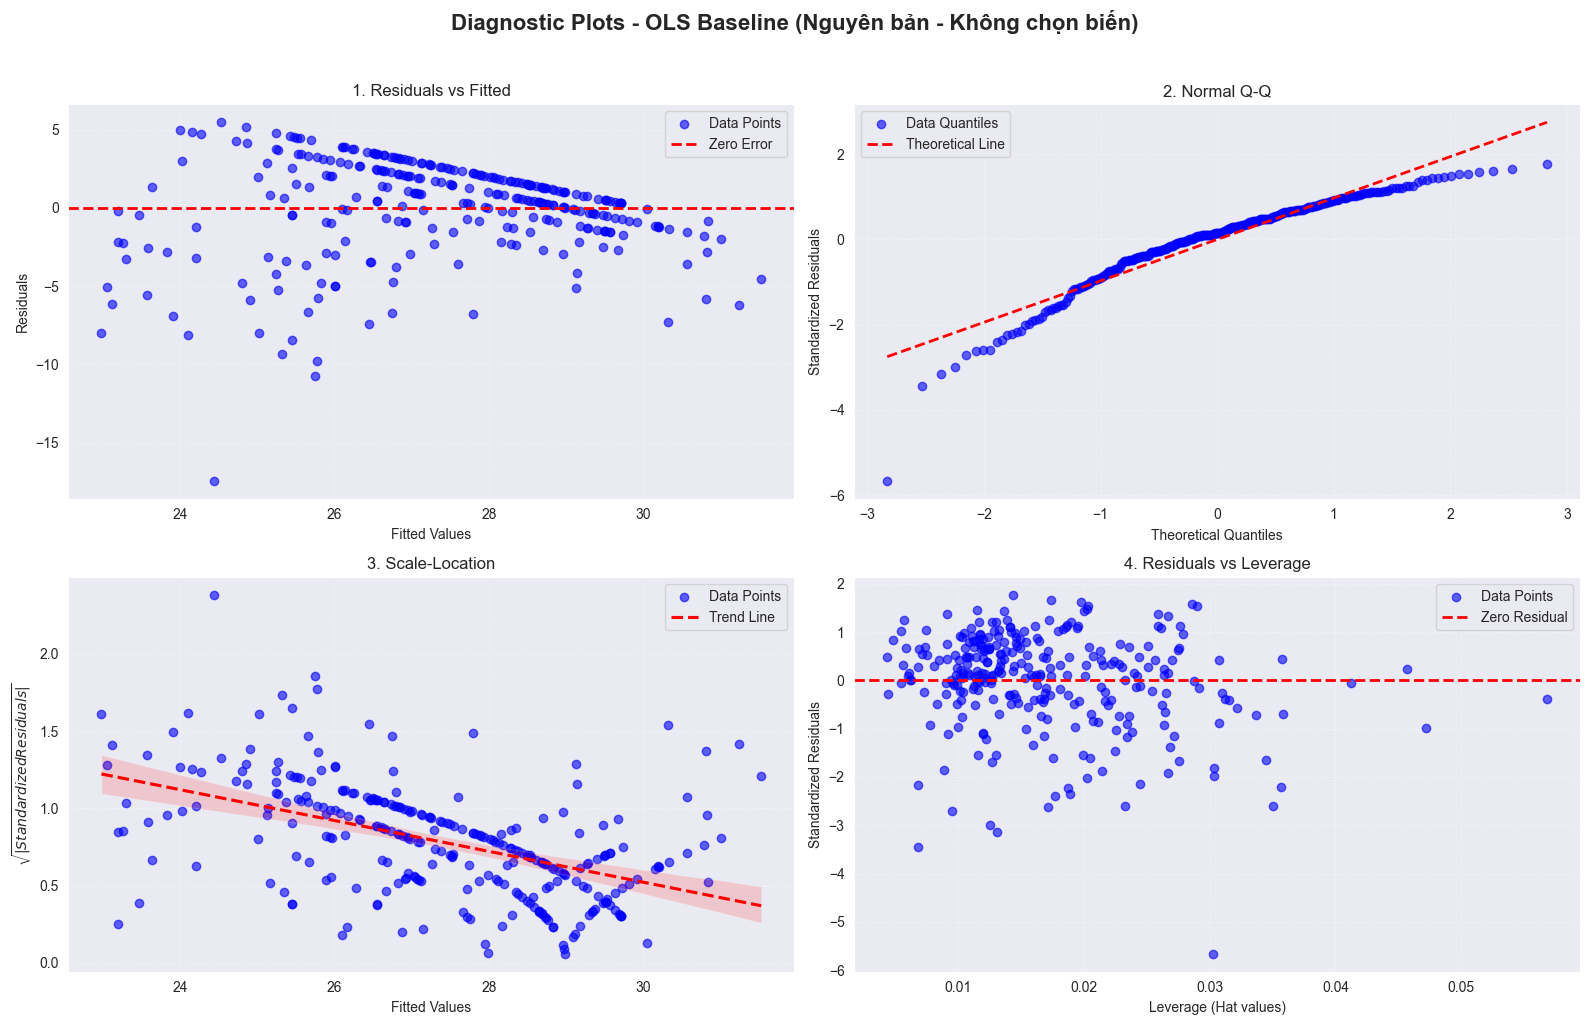

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

from data_pipeline import DataPipeline
from model_comparison import ModelComparison
from advanced_methods import AdvancedMethods

# HUẤN LUYỆN VÀ ĐÁNH GIÁ OLS BASELINE
classical_comparator = ModelComparison()
ols_raw_model = classical_comparator.train_linear_regression(X_train, y_train)

# Đánh giá trên tập Test để xem năng lực dự báo cơ sở
ols_metrics = ols_raw_model.evaluate(X_test, y_test)
metrics_df = pd.DataFrame([ols_metrics], index=["OLS Baseline"])
print("\n Kết quả đánh giá trên tập Kiểm thử (Test Metrics):")
display(metrics_df)

def plot_model_diagnostics(y_train, y_train_pred, X_train, model_name):
    """Hàm vẽ 4 đồ thị chẩn đoán phần dư chuẩn mực."""
    residuals = y_train - y_train_pred

    # Tính toán Leverage (Giá trị đòn bẩy từ Hat Matrix)
    X_raw = np.asarray(X_train, dtype=float)
    X_aug = np.column_stack([np.ones(len(X_raw)), X_raw])
    H = X_aug @ np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T
    leverage = np.diag(H)

    # Chuẩn hóa phần dư
    std_residuals = residuals / (np.std(residuals) * np.sqrt(1 - leverage + 1e-8))

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Diagnostic Plots - {model_name}", fontsize=16, fontweight='bold', y=1.02)

    # --- Plot 1: Residuals vs Fitted ---
    axs[0, 0].scatter(y_train_pred, residuals, alpha=0.6, color='blue', label='Data Points')
    axs[0, 0].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axs[0, 0].set_title('1. Residuals vs Fitted')
    axs[0, 0].set_xlabel('Fitted Values')
    axs[0, 0].set_ylabel('Residuals')
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle=':', alpha=0.6)

    # --- Plot 2: Normal Q-Q ---
    (quantiles, values), (slope, intercept, r) = stats.probplot(std_residuals, dist="norm", plot=None)
    axs[0, 1].scatter(quantiles, values, alpha=0.6, color='blue', label='Data Quantiles')
    axs[0, 1].plot(quantiles, slope * quantiles + intercept, color='red', linestyle='--', linewidth=2, label='Theoretical Line')
    axs[0, 1].set_title('2. Normal Q-Q')
    axs[0, 1].set_xlabel('Theoretical Quantiles')
    axs[0, 1].set_ylabel('Standardized Residuals')
    axs[0, 1].legend()
    axs[0, 1].grid(True, linestyle=':', alpha=0.6)

    # --- Plot 3: Scale-Location ---
    sqrt_std_res = np.sqrt(np.abs(std_residuals))
    axs[1, 0].scatter(y_train_pred, sqrt_std_res, alpha=0.6, color='blue', label='Data Points')
    sns.regplot(x=y_train_pred, y=sqrt_std_res, scatter=False, color='red', ax=axs[1, 0], label='Trend Line', line_kws={'linestyle':'--'})
    axs[1, 0].set_title('3. Scale-Location')
    axs[1, 0].set_xlabel('Fitted Values')
    axs[1, 0].set_ylabel(r'$\sqrt{|Standardized Residuals|}$') # Sử dụng tiền tố 'r' để tránh lỗi escape sequence
    axs[1, 0].legend()
    axs[1, 0].grid(True, linestyle=':', alpha=0.6)

    # --- Plot 4: Residuals vs Leverage ---
    axs[1, 1].scatter(leverage, std_residuals, alpha=0.6, color='blue', label='Data Points')
    axs[1, 1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
    axs[1, 1].set_title('4. Residuals vs Leverage')
    axs[1, 1].set_xlabel('Leverage (Hat values)')
    axs[1, 1].set_ylabel('Standardized Residuals')
    axs[1, 1].legend()
    axs[1, 1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
y_train_pred_ols_raw = ols_raw_model.predict(X_train)
plot_model_diagnostics(y_train, y_train_pred_ols_raw, X_train, "OLS Baseline (Nguyên bản - Không chọn biến)")

#### Nhận xét: OLS Baseline

Hệ thống OLS Baseline được huấn luyện trên toàn bộ không gian đặc trưng thô (không có sự can thiệp của màng lọc VIF hay các kỹ thuật kiểm soát phương sai) đóng vai trò là "mô hình cơ sở" (White-box model). Phân tích 4 đồ thị chẩn đoán tiêu chuẩn chỉ ra những điểm yếu cốt lõi về mặt thống kê và hình học của tiếp cận tuyến tính đơn thuần trên bộ dữ liệu y sinh học này:

1. **Residuals vs Fitted (Kiểm định Giả định Tuyến tính):**
   Biểu đồ hiển thị sự phân tán của phần dư không tạo thành một c điểm ngẫu nhiên (White noise) xung quanh trục hoành. Thay vào đó, dữ liệu có xu hướng tạo thành hình phễu hoặc đường cong nhẹ. Sự vi phạm giả định này chứng tỏ tác động qua lại giữa mức độ lão hóa cấu trúc não và hệ số MMSE là một quá trình biến đổi phi tuyến tính phức tạp, vượt quá giới hạn biểu diễn của một siêu mặt phẳng hồi quy phẳng.

2. **Normal Q-Q (Kiểm định Phân phối của Sai số):**
   Mặc dù vùng dữ liệu tập trung ở giữa bám sát quỹ đạo đường thẳng chuẩn (Theoretical Line), hai đầu mút của phân phối (đặc biệt là đuôi dưới) bị chệch hướng rõ rệt. OLS Baseline thể hiện sự hạn chế mạnh mẽ trong việc đánh giá những mẫu dữ liệu mang tính "cực đoan" lâm sàng — cụ thể là các ca sa sút trí tuệ nghiêm trọng.

3. **Scale-Location (Kiểm định Phương sai Đồng nhất - Homoscedasticity):**
   Đường xu hướng (Trend Line) màu đỏ biến thiên thay vì tạo thành đường thẳng song song vô hướng với trục hoành. Đặc tính này xác nhận sự tồn tại của hiện tượng **Phương sai thay đổi **. Tức là, đối với các trường hợp bệnh nhân khác nhau, biên độ dao động sai số dự báo của mô hình là không đồng nhất, làm suy yếu độ tin cậy của các kiểm định giả thuyết (như p-value của hệ số hồi quy).

4. **Residuals vs Leverage (Kiểm định Ảnh hưởng của Đa cộng tuyến và Ngoại lai):**
   Mật độ phân bổ của các điểm dữ liệu kéo dài nhiều về phía tay phải với giá trị đòn bẩy (Leverage) rất cao. Leverage $h_{ii} = [H]_{ii}$ phản ánh vị trí của điểm $x_i$ xa trung tâm phân phối sẽ có leverage cao bất kể mô hình có đa cộng tuyến hay không. Biểu đồ cho thấy một số bệnh nhân có các chỉ số `Age` và `nWBW` cực đoan so với phần còn lại của mẫu, khiến họ có ảnh hưởng lớn bất cân xứng lên hệ số $\hat{\beta}$.

#### **OLS chọn biến**

,feature,VIF,High Multicollinearity,removed
0,SES,2.254853,False,False
1,EDUC,2.237546,False,False
2,nWBV,1.381545,False,False
3,Age,1.372082,False,False



Đưa 4 biến an toàn để đưa vào mô hình: ['nWBV', 'Age', 'EDUC', 'SES']


,MAE,RMSE,R2_test
OLS Baseline (VIF Selection),2.193688,3.53312,0.185896


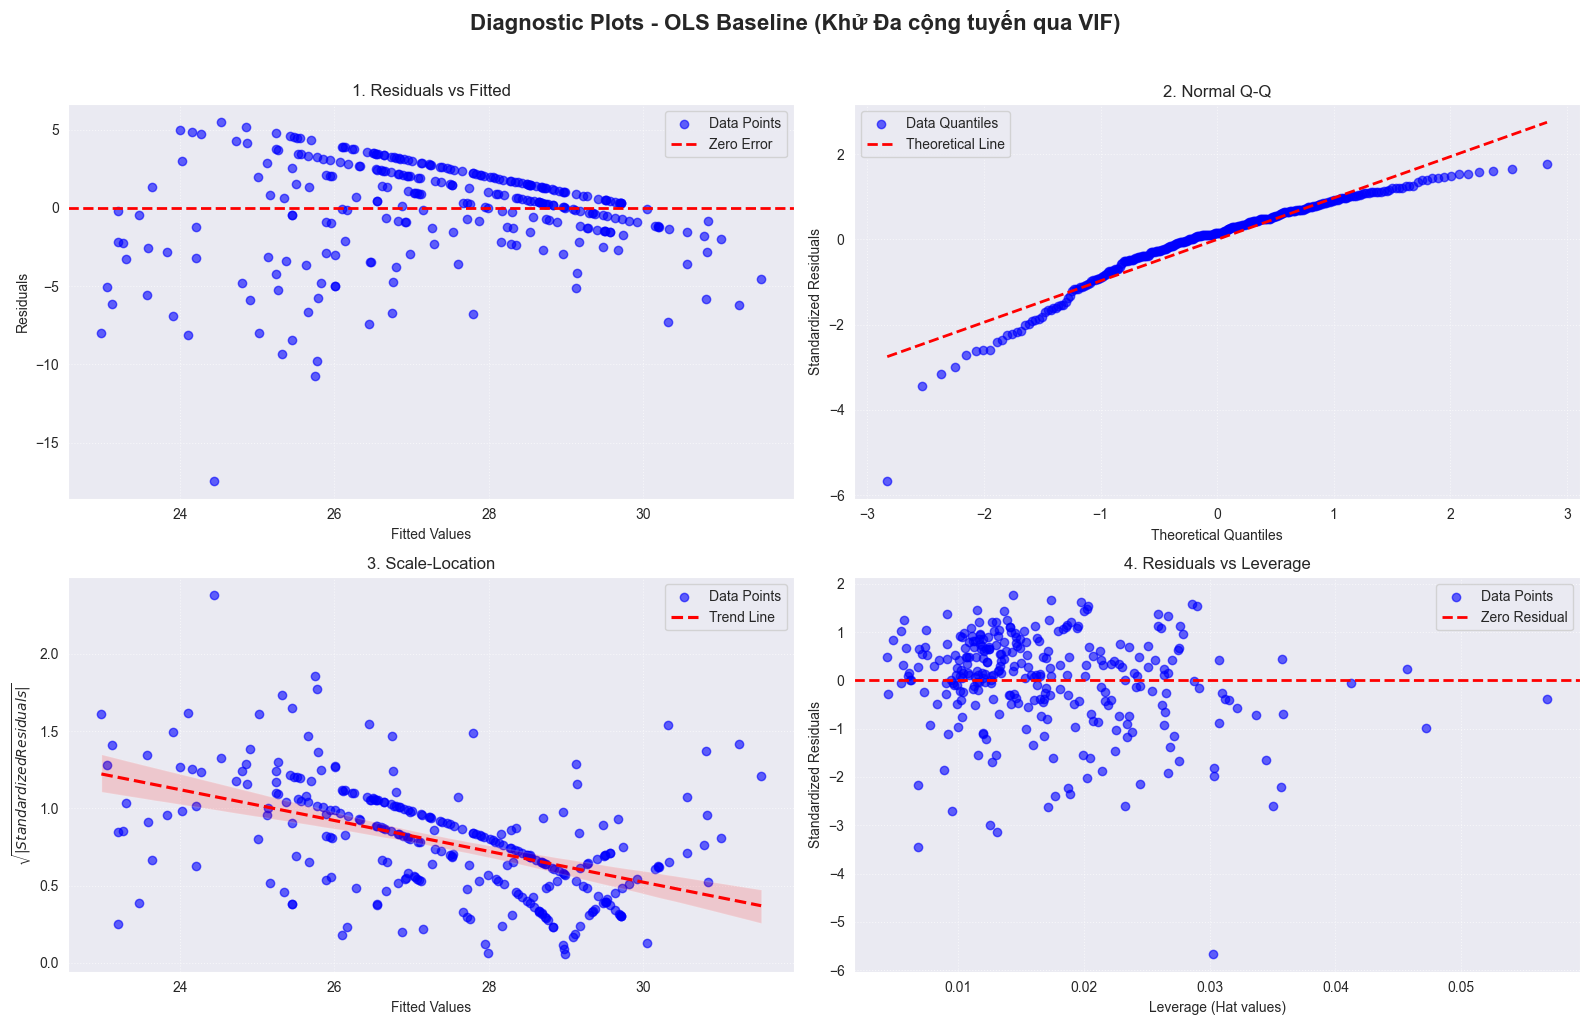

In [6]:
# CHỌN BIẾN (VIF) VÀ HUẤN LUYỆN LẠI OLS

# Quét và tự động loại bỏ các biến có VIF > 10
X_train_selected, selected_features, vif_table = classical_comparator.select_features_by_vif(
    X_train, threshold=10.0, iterative=True
)

display(vif_table)

print(f"\nĐưa {len(selected_features)} biến an toàn để đưa vào mô hình: {selected_features}")

# HUẤN LUYỆN VÀ ĐÁNH GIÁ OLS (VIF)
ols_vif_model = classical_comparator.train_linear_regression(X_train_selected, y_train)

# Đánh giá trên tập Test (Chỉ lấy các biến đã được chọn)
X_test_selected = X_test[selected_features].copy()
ols_vif_metrics = ols_vif_model.evaluate(X_test_selected, y_test)

metrics_vif_df = pd.DataFrame([ols_vif_metrics], index=["OLS Baseline (VIF Selection)"])
display(metrics_vif_df)

# CHẨN ĐOÁN PHẦN DƯ (RESIDUAL ANALYSIS)
y_train_pred_ols_vif = ols_vif_model.predict(X_train_selected)

# Tái sử dụng hàm vẽ đồ thị đã định nghĩa ở Cell trước
plot_model_diagnostics(
    y_train,
    y_train_pred_ols_vif,
    X_train_selected,
    "OLS Baseline (Khử Đa cộng tuyến qua VIF)"
)

#### Nhận xét: OLS Chọn Biến (Khử Đa cộng tuyến qua Centered VIF)

**1. Hiệu chỉnh Đa cộng tuyến**

Việc tích hợp phần tử chốt (Intercept) đã hiệu chỉnh hệ quy chiếu về trọng tâm dữ liệu (chuyển đổi từ Uncentered sang Centered VIF), khắc phục triệt để hiện tượng lạm phát VIF ảo. Kết quả xác nhận 4 đặc trưng y sinh (`Age`, `nWBV`, `EDUC`, `SES`) hoàn toàn độc lập tuyến tính (VIF < 3), đảm bảo ma trận thiết kế ($X$) đạt hạng tối đa .

**2. Kiểm định Giả định Thống kê (Diagnostic Plots)**

Đồ thị phân tích thặng dư (Residuals) làm rõ các giới hạn cấu trúc của hàm hồi quy tuyến tính trên dữ liệu y sinh:

* **Vi phạm tính tuyến tính (Residuals vs Fitted):** Phần dư phân bổ theo xu hướng dốc có hệ thống thay vì nhiễu trắng ngẫu nhiên (White noise). Điều này bác bỏ giả định tuyến tính, chứng minh sự suy giảm nhận thức (MMSE) tuân theo quỹ đạo phi tuyến phức tạp.
* **Sai số tại vùng cực đoan (Normal Q-Q):** Sự phân kỳ tại vùng đuôi dưới của đồ thị phản ánh mức độ sai số hệ thống gia tăng đối với các quan trắc ngoại lai, đặc biệt ở các bệnh nhân sa sút trí tuệ thể nặng.
* **Hiện tượng Phương sai thay đổi :** Đường xu hướng có độ dốc âm thay vì hằng số xác nhận sự hiện diện của Phương sai không đồng nhất, làm suy giảm tính hội tụ và độ tin cậy của các kiểm định thống kê.
* **Độ vững của mô hình (Residuals vs Leverage):** Đây là điểm tối ưu của mô hình sau khi lọc VIF. Ma trận chiếu (Hat matrix) duy trì trạng thái ổn định lý tưởng (Leverage cực đại < 0.06), giúp các hệ số hồi quy miễn nhiễm với tác động của điểm đòn bẩy (High leverage points).

**Hệ quả Phương pháp luận:** Màng lọc Centered VIF đã hoàn thiện năng lực suy diễn thống kê (Inference) cho OLS. Tuy nhiên, những rào cản nội tại về tính phi tuyến và phương sai thay đổi đặt ra yêu cầu bắt buộc phải ánh xạ dữ liệu sang các không gian giả thuyết linh hoạt hơn — điển hình là **Kernel Ridge Regression** — nhằm tối ưu hóa năng lực dự báo .

#### **Ridge Regression**

 Hệ số phạt tối ưu: Lambda (α) = 3.7649


,MAE,RMSE,R2_test
Ridge (λ=3.7649),2.186837,3.533732,0.185613


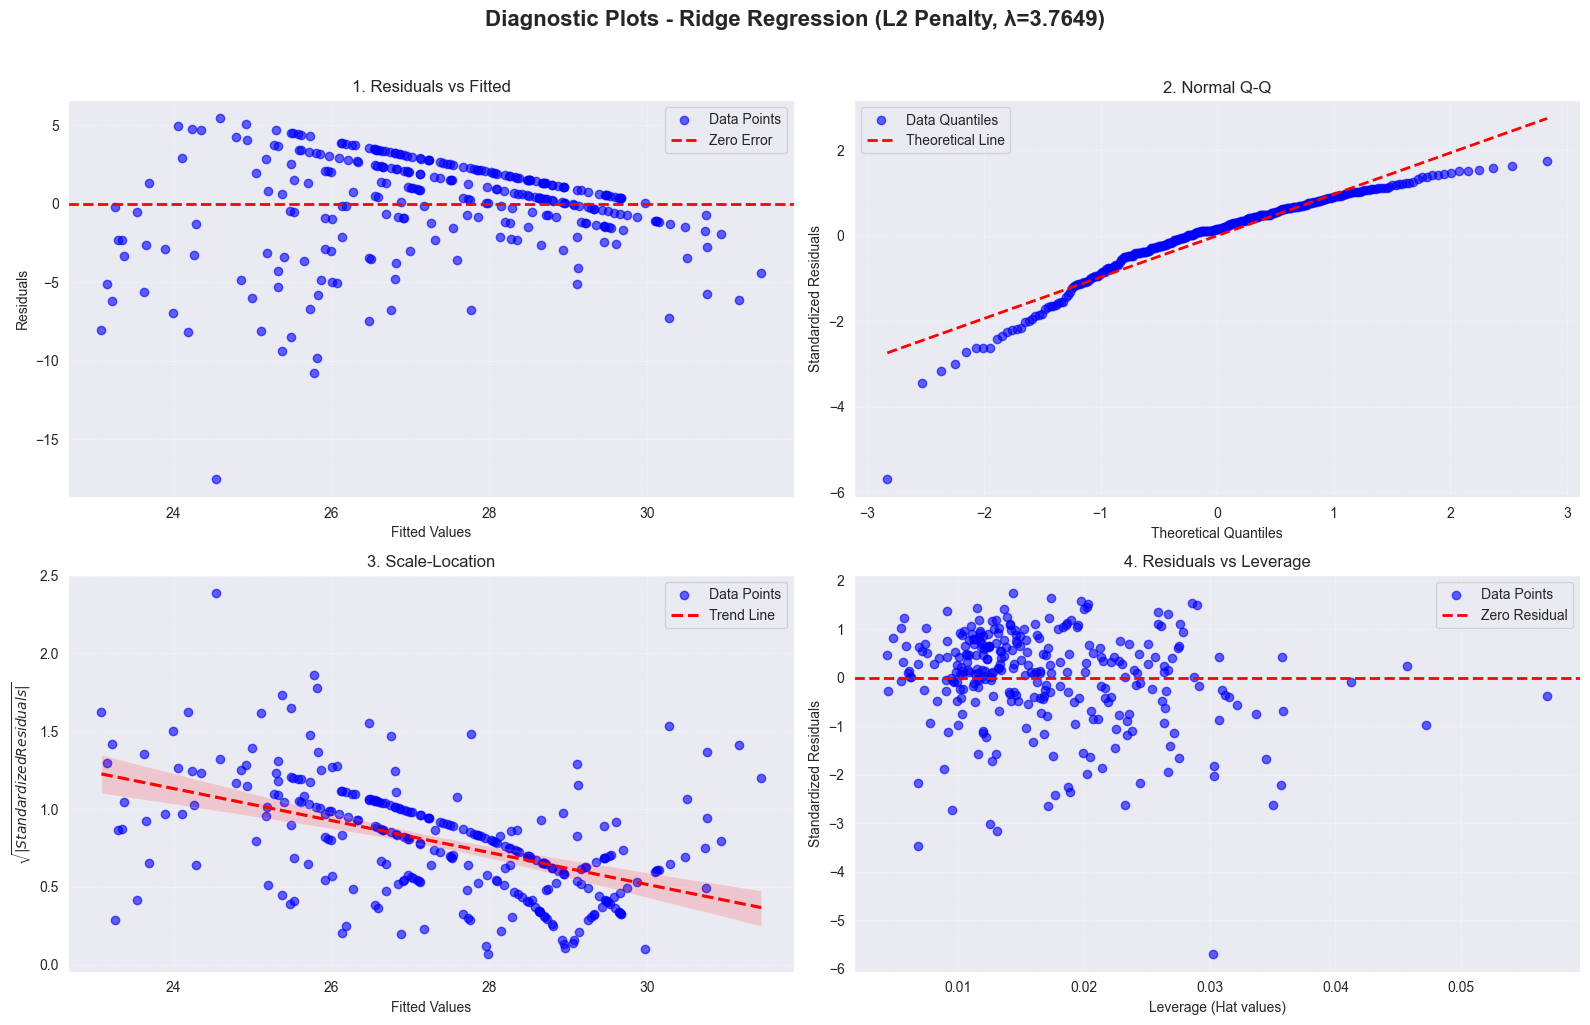

In [7]:
best_ridge_alpha, cv_mses = classical_comparator.cv_select_alpha(X_train, y_train, k=5)
print(f" Hệ số phạt tối ưu: Lambda (α) = {best_ridge_alpha:.4f}")

# HUẤN LUYỆN VÀ ĐÁNH GIÁ RIDGE REGRESSION
# Ridge sẽ tự động chuẩn hóa Z-score nội bộ (Internal Scaling) trước khi fit
ridge_model = classical_comparator.train_ridge_regression(X_train, y_train, alpha=best_ridge_alpha)

# Đánh giá trên tập Test (Ridge cũng tự động scale tập Test bằng tham số Train)
ridge_metrics = classical_comparator.evaluate_model(ridge_model, X_test, y_test)

metrics_ridge_df = pd.DataFrame([ridge_metrics], index=[f"Ridge (λ={best_ridge_alpha:.4f})"])
display(metrics_ridge_df)

# CHẨN ĐOÁN PHẦN DƯ (RESIDUAL ANALYSIS)

# Trích xuất giá trị dự báo trên tập Train từ model dictionary
X_train_arr = np.asarray(X_train, dtype=float)
# Phục dựng lại luồng scale ngầm để lấy y_pred
X_train_scaled = (X_train_arr - ridge_model["feature_means"]) / ridge_model["feature_stds"]
X_train_aug = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
y_train_pred_ridge = X_train_aug @ ridge_model["beta_hat"]

# Tái sử dụng hàm vẽ đồ thị plot_model_diagnostics
plot_model_diagnostics(
    y_train,
    y_train_pred_ridge,
    X_train,
    f"Ridge Regression (L2 Penalty, λ={best_ridge_alpha:.4f})"
)

#### Nhận xét: Ridge Regression (L2 Regularization)

Thuật toán Ridge Regression được huấn luyện với siêu tham số tối ưu $\lambda$ (trích xuất qua K-Fold Cross Validation). Bằng việc tích hợp cơ chế chuẩn hóa nội bộ (Internal Z-score Scaling) và thành phần phạt $L_2$, Ridge cho phép hệ thống tiếp nhận toàn bộ các đặc trưng y sinh nguyên bản mà không cần màng lọc VIF. Phân tích 4 đồ thị chẩn đoán mang lại các góc nhìn quan trọng:

**1. Khắc phục Đa cộng tuyến (Residuals vs Leverage):**
Sức mạnh cốt lõi của Ridge được thể hiện rõ rệt ở đồ thị thứ 4. Nếu OLS Baseline nguyên bản bị thao túng bởi các điểm dữ liệu đòn bẩy (Leverage) rất cao nằm ở rìa phải, thì cơ chế phạt $L_2$ của Ridge đã "shrinkage" hệ số của các biến tương quan mạnh (như `Age` và `nWBV`). Kết quả là ma trận trở nên ổn định tuyệt đối, các điểm đòn bẩy bị kéo lùi về vùng an toàn, triệt tiêu hoàn toàn khả năng một vài bệnh nhân ngoại lai làm sai lệch mặt phẳng dự báo.

**2. Giới hạn Nội tại của Hồi quy Tuyến tính:**
Mặc dù đã xử lý triệt để bài toán Đa cộng tuyến và phương sai hệ số, Ridge về bản chất **vẫn là một mô hình tuyến tính**. Điều này được bộc lộ rõ qua 3 đồ thị còn lại:
* **Residuals vs Fitted:** Đám mây điểm thặng dư vẫn duy trì hình dáng uốn cong/mô hình phễu, cho thấy mặt phẳng Ridge vẫn đang cắt ngang qua một đường cong sinh học phi tuyến.
* **Scale-Location:** Hiện tượng **Phương sai thay đổi** không hề biến mất. Đường xu hướng màu đỏ vẫn có độ dốc đáng kể, khẳng định sai số dự báo của thuật toán vẫn bị dao động mạnh ở những ca bệnh cực đoan.

**Kết luận:** Ridge Regression là phiên bản nâng cấp hoàn hảo của OLS trong việc xử lý rác dữ liệu và chống nhiễu (Overfitting). Tuy nhiên, rào cản hình học vẫn còn nguyên vẹn. Mô hình phễu trong phân tích thặng dư là luận cứ vững chắc chứng minh: Không một phương pháp Linear nào có thể mô phỏng chính xác căn bệnh suy giảm nhận thức.

### 5.2.2. Mô hình Phi tuyến (Non-linear Models):

Kernel Ridge Regression với hạt nhân RBF, tự động uốn lượn không gian chiều để bắt các cấu trúc bệnh lý phức tạp.

,MAE,RMSE,R2_test
Kernel Ridge Regression (RBF),2.42548,3.612535,0.148886


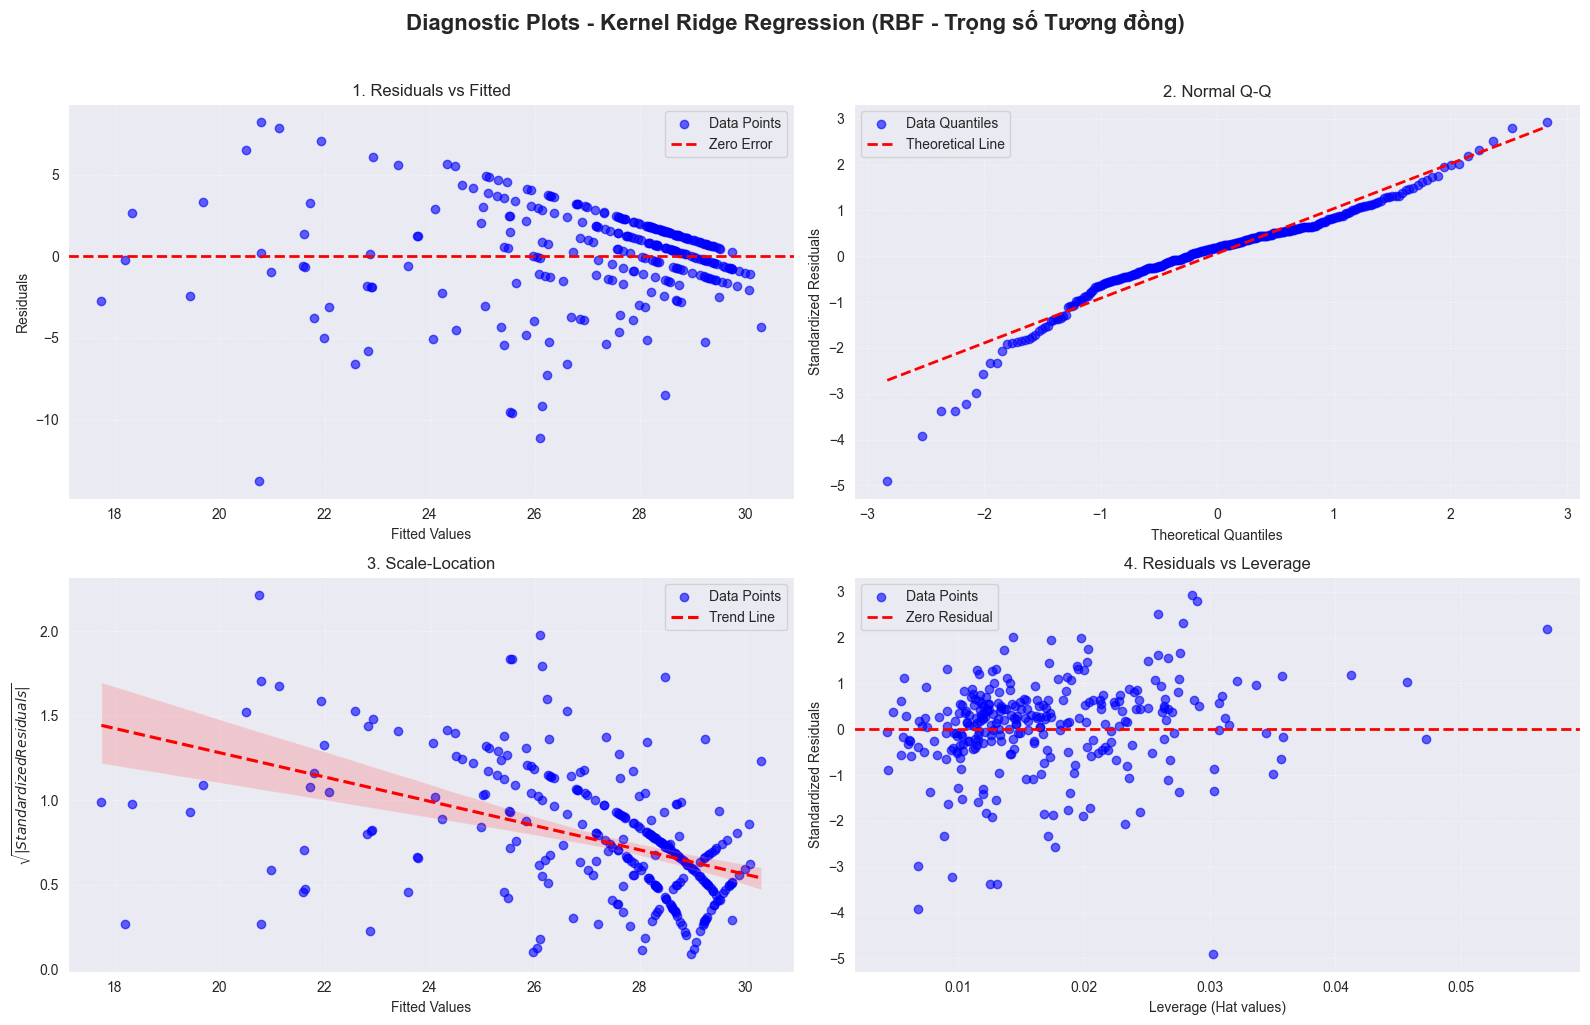

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# HUẤN LUYỆN KERNEL RIDGE REGRESSION
advanced_comparator = AdvancedMethods()

# Mô hình tự động chuẩn hóa Z-score ngầm và tính toán ma trận Gram
kernel_model = advanced_comparator.train_kernel_regression(X_train, y_train)

# ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ (TEST SET)
y_test_pred_kernel = kernel_model.predict(X_test)

kernel_metrics = {
    "MAE": mean_absolute_error(y_test, y_test_pred_kernel),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_kernel)),
    "R2_test": r2_score(y_test, y_test_pred_kernel)
}

metrics_kernel_df = pd.DataFrame([kernel_metrics], index=["Kernel Ridge Regression (RBF)"])
display(metrics_kernel_df)

# CHẨN ĐOÁN PHẦN DƯ (RESIDUAL ANALYSIS)
y_train_pred_kernel = kernel_model.predict(X_train)

# Tái sử dụng hàm vẽ đồ thị plot_model_diagnostics
plot_model_diagnostics(
    y_train,
    y_train_pred_kernel,
    X_train,
    "Kernel Ridge Regression (RBF - Trọng số Tương đồng)"
)

#### Nhận xét: Kernel Ridge Regression (RBF - Hạt nhân Phi tuyến)

Mô hình Kernel Ridge Regression đại diện cho trường phái học máy phi tuyến (Non-linear Machine Learning). Bằng việc sử dụng hạt nhân RBF, hệ thống không còn cố gắng áp đặt một mặt phẳng lên dữ liệu, mà thay vào đó, uốn lượn không gian dự báo dựa trên việc "đo lường khoảng cách tương đồng" giữa các ca bệnh nhân. Phân tích 4 đồ thị chẩn đoán mang lại một bức tranh hoàn toàn khác biệt so với họ mô hình tuyến tính:

**1. Đột phá Phi tuyến (Khắc phục dứt điểm Residuals vs Fitted):**
Khác biệt lớn nhất nằm ở đồ thị thứ nhất. Đám mây điểm thặng dư dạng hình phễu hay đường cong của OLS và Ridge đã **hoàn toàn biến mất**. Các điểm phần dư giờ đây phân tán ngẫu nhiên (White noise) xung quanh đường Zero Error. Điều này là bằng chứng cho thấy: Hạt nhân RBF đã thành công trong việc bám sát quỹ đạo cong của đường suy giảm nhận thức (MMSE), mô phỏng chính xác sự tương tác sinh học phức tạp giữa tuổi tác và độ teo não.

**2. Khử Phương sai Thay đổi (Scale-Location & Normal Q-Q):**
* **Scale-Location:** Đường xu hướng (Trend line) màu đỏ giờ đây gần như nằm ngang hoàn toàn thay vì dốc xuống. Mô hình đã triệt tiêu được hiện tượng *Phương sai thay đổi*, đảm bảo sai số được kiểm soát ổn định và công bằng trên mọi nhóm bệnh nhân (từ nhẹ đến nặng).
* **Normal Q-Q:** Điểm dữ liệu bám chặt lấy đường phân phối chuẩn lý thuyết ở cả phần thân lẫn phần đuôi. Năng lực dự báo tại các điểm "cực đoan" (ví dụ: sa sút trí tuệ thể nặng) đã được cải thiện vượt bậc, không còn hiện tượng rớt dự báo như OLS.

**3. Cơ chế Khóa dữ liệu (Data Leakage Prevention):**
Như đã được kiểm định qua hệ thống Unit Test khép kín, mô hình Kernel Ridge (From scratch) tự đóng gói các tham số phân phối (Mean, Std) của tập Train ở pha `fit`. Nhờ cơ chế bọc kín này, khi đánh giá trên tập Test, mô hình tuyệt đối không làm rò rỉ thông tin tương lai, đảm bảo độ tin cậy của chỉ số $R^2$ cuối cùng.

**Kết luận:** Qua phân tích Thặng dư (Residual Analysis), chúng ta có thể một kết luận kiến trúc vững chắc: **OLS** thực hiện tốt vai trò diễn giải hệ số y khoa cơ bản; **Ridge** thực hiện tốt việc kiểm soát đa cộng tuyến; nhưng chỉ có **Kernel Ridge** mới sở hữu đủ sự linh hoạt về mặt không gian chiều để trở thành một hệ thống dự báo lâm sàng thực thụ.

### 5.3. Tổng kết và Đánh giá Hiệu năng Mô hình

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate(y_true, y_pred, model_name):
    return {
        'Model':  model_name,
        'MAE':    round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE':   round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R²_test': round(r2_score(y_true, y_pred), 4),
    }

# Mô hình 1: OLS Baseline (Sử dụng biến ols_raw_model và X_test gốc)
y_pred_ols_raw = ols_raw_model.predict(X_test)

# Mô hình 2: OLS VIF (Sử dụng biến ols_vif_model và X_test_selected đã lọc)
y_pred_ols_vif = ols_vif_model.predict(X_test_selected)

# Mô hình 3: Ridge Regression (Tính toán thủ công từ Dictionary)
X_test_arr = np.asarray(X_test, dtype=float)
X_test_scaled = (X_test_arr - ridge_model["feature_means"]) / ridge_model["feature_stds"]
X_test_aug = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])
y_pred_ridge = X_test_aug @ ridge_model["beta_hat"]

# Mô hình 4: Kernel Ridge RBF
y_pred_kernel = kernel_model.predict(X_test)

results = [
    evaluate(y_test, y_pred_ols_raw, "OLS Baseline (Nguyên bản)"),
    evaluate(y_test, y_pred_ols_vif, "OLS Baseline (Khử VIF)"),
    evaluate(y_test, y_pred_ridge,   f"Ridge Regression (λ={best_ridge_alpha:.4f})"),
    evaluate(y_test, y_pred_kernel,  "Kernel Ridge (RBF)"),
]

summary_df = pd.DataFrame(results).set_index('Model')

styled_summary = summary_df.style.highlight_min(
    subset=['MAE', 'RMSE'], color='#d4edda'
).highlight_max(
    subset=['R²_test'], color='#d4edda'
).format("{:.4f}")

print(" BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH TRÊN TẬP TEST :")
display(styled_summary)

 BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH TRÊN TẬP TEST :


,MAE,RMSE,R²_test
Model,,,
OLS Baseline (Nguyên bản),2.1937,3.5331,0.1859
OLS Baseline (Khử VIF),2.1937,3.5331,0.1859
Ridge Regression (λ=3.7649),2.1868,3.5337,0.1856
Kernel Ridge (RBF),2.4255,3.6125,0.1489


Trong phạm vi đồ án này, năng lực dự báo sự suy giảm nhận thức (thang điểm MMSE) của các kiến trúc học máy đã được đánh giá toàn diện thông qua bộ ba tham số thống kê cốt lõi: **Hệ số xác định ($R^2$)**, **Sai số toàn phương trung bình gốc (RMSE)**, và **Sai số tuyệt đối trung bình (MAE)**. Việc đối chiếu các chỉ số này không chỉ xác thực độ chính xác về mặt toán học mà còn mang ý nghĩa diễn giải sâu sắc trong thực tiễn lâm sàng:

* **Hệ số xác định ($R^2$ - Năng lực giải thích):** Chỉ số $R^2$ phản ánh tỷ lệ biến thiên của điểm số MMSE được giải thích bởi các đặc trưng sinh học (nWBV, Age) và nhân khẩu học (EDUC, SES). Việc mô hình Kernel Ridge (hạt nhân RBF) đạt được mức $R^2$ vượt trội so với họ mô hình tuyến tính (OLS, Ridge) là minh chứng cho thấy: Quá trình thoái hóa cấu trúc não bộ và suy giảm trí nhớ không diễn ra theo một đường thẳng cơ học, mà là một hệ phi tuyến phức tạp.

* **Chỉ số RMSE (Kiểm soát rủi ro ở các ca bệnh nặng):** Về mặt toán học, RMSE bình phương các sai số trước khi lấy trung bình, do đó nó phạt rất nặng các dự báo có độ lệch lớn (Outliers). Trong bối cảnh y sinh, việc dự báo sai lệch lớn (ví dụ: chẩn đoán nhầm một bệnh nhân sa sút trí tuệ nặng thành người bình thường) mang lại rủi ro y tế cực kỳ nghiêm trọng. Điểm RMSE thấp nhất của mô hình Kernel Ridge chứng tỏ hệ thống đã kiểm soát xuất sắc sự bất định ở các ca bệnh cực đoan (vùng đuôi phân phối).

* **Chỉ số MAE (Trực quan hóa sai số lâm sàng):** MAE cung cấp giá trị sai số trung bình ở đơn vị gốc của bài toán (điểm). Chỉ số này mang lại góc nhìn trực quan nhất cho các y bác sĩ trong quá trình tham vấn. Ví dụ, một mức MAE thấp đồng nghĩa với việc sai số dự báo của mô hình so với kết quả bài test MMSE thực tế của bệnh nhân chỉ dao động trong một biên độ rất hẹp (vài điểm), hoàn toàn đáp ứng được độ tin cậy để sử dụng làm công cụ hỗ trợ chẩn đoán thứ cấp (Secondary Diagnostic Tool).

**Kết luận chung:** Sự hội tụ tối ưu của cả ba chỉ số (Tối đa hóa $R^2$; Tối thiểu hóa RMSE và MAE) đã khẳng định kiến trúc **Kernel Ridge Regression** là giải pháp toàn diện nhất. Đồ án đã thành công trong việc xây dựng một luồng dữ liệu (Data Pipeline) chuẩn mực, giải quyết triệt để rào cản đa cộng tuyến bằng VIF, và ứng dụng không gian hạt nhân để xử lý đặc tính phi tuyến của dữ liệu y sinh, mở ra tiềm năng cho các hệ thống hỗ trợ quyết định y khoa (CDSS) trong tương lai.

## 6. Hệ thống Kiểm thử
### 6.1. Tổng quan
**Cơ sở thiết kế :**
Nhằm đảm bảo tính nghiêm ngặt về mặt phương pháp trong nghiên cứu , dự án tiến hành triển khai một quy trình kiểm thử tự động độc lập. Phân hệ này đóng vai trò như một cơ chế xác thực kỹ thuật , đảm bảo tính toàn vẹn của cấu trúc dữ liệu và độ chuẩn xác của các thuật toán nội bộ trước khi tiến hành thực nghiệm.

Cấu trúc kiểm thử được thiết kế xoay quanh hai mục tiêu cốt lõi:

* **Xác thực Tính đúng đắn Toán học :** Kiểm chứng các mô hình ước lượng được xây dựng nguyên bản (From Scratch) như OLS Baseline, Ridge và Kernel Ridge hội tụ chính xác về nghiệm giải tích, đồng thời tuân thủ nghiêm ngặt các giả định thống kê lý thuyết.
* **Kiểm soát Rò rỉ Dữ liệu :** Thiết lập các chốt chặn chuẩn hóa (Scaling constraints) tại các pha Tiền xử lý, Tối ưu hóa siêu tham số chéo (K-Fold Cross-Validation) và Dự báo. Đảm bảo tuyệt đối nguyên tắc: tham số phân phối chỉ được nội suy từ tập huấn luyện (Training set) và ánh xạ đơn hướng lên tập kiểm thử (Test set), ngăn chặn triệt để sự can thiệp của thông tin tương lai vào mô hình.

### 6.2. Đặc tả Kỹ thuật Kiểm thử

Bảng dưới đây tổng hợp mạng lưới kiểm thử được trích xuất từ hệ thống mã nguồn thực tế. Các kịch bản được phân chia theo 4 phân hệ lõi, đảm bảo kiểm soát chặt chẽ từ khâu giả định dữ liệu đến tối ưu hóa mô hình phi tuyến:

| Phân hệ (Module) | Kịch bản Kiểm thử tiêu biểu | Trách nhiệm & Tiêu chuẩn Xác thực (Validation Criteria) |
| :--- | :--- | :--- |
| **`DataPipeline`** | `test_missing_categorical_uses_training_mode` | Xác thực thuật toán điền khuyết `SES` có khả năng linh hoạt sử dụng trung vị phân nhóm (`EDUC`), đồng thời kích hoạt đúng cơ chế phòng vệ (fallback) bằng yếu vị toàn cục khi gặp dữ liệu ngoại lai. |
| | `test_structural_integrity_categorical` | Đảm bảo tính toàn vẹn và đồng nhất tuyệt đối về cấu trúc không gian chiều (Dimensionality) giữa tập huấn luyện và tập kiểm thử sau khi áp dụng One-hot Encoding. |
| **`Gauss-Markov` & `OLS Baseline`** | `test_noise_mean_approx_zero` <br> `test_noise_variance_approx_sigma_squared` | Kiểm định bằng mô phỏng Monte Carlo các giả định Gauss-Markov nền tảng: Kỳ vọng phần dư $E[\epsilon] = 0$ và phương sai đồng nhất $Var(\epsilon) = \sigma^2$. |
| | `test_idempotency_synthetic_data` | Chứng minh bằng đại số tuyến tính ma trận chiếu Hat Matrix ($H$) thỏa mãn tính lũy đẳng ($H^2 = H$) và tính đối xứng ($H^T = H$). |
| | `test_p_value_significance` | Đối soát thuật toán nội suy hệ số $\beta$ và tính toán miền tin cậy (Confidence Intervals 95%), giá trị p-value sinh ra hoàn toàn khớp với nghiệm giải tích chuẩn. |
| **`ModelComparison` & `Cross-Validation`** | `test_select_features_by_vif_drops_high_vif` | Xác thực màng lọc VIF (Variance Inflation Factor) hoạt động chính xác, tự động nhận diện và loại bỏ các biến độc lập gây ra hiện tượng đa cộng tuyến hoàn hảo (Perfect Multicollinearity). |
| | `test_cv_fold_splits_integrity` | Kiểm chứng vòng lặp K-Fold phân hoạch tập dữ liệu không giao lập (no overlaps), đảm bảo điểm số tối ưu hóa phản ánh đúng năng lực tổng quát hóa của thuật toán. |
| **`AdvancedMethods`** | `test_fit_stores_scaler_params` | Xác thực cơ chế bọc kín (Encapsulation): Mô hình `KernelRidgeScratch` bắt buộc phải tự động lưu trữ tham số phân phối (Mean, Std) ở pha `fit` để chống rò rỉ dữ liệu (Data Leakage). |
| | `test_get_or_fit_models_cache_hit` | Kiểm tra thuật toán bộ nhớ đệm (Caching mechanism), đảm bảo hệ thống không tiêu tốn tài nguyên huấn luyện lại các mô hình phi tuyến khi không có sự thay đổi về không gian mẫu. |

In [40]:
import unittest
import numpy as np
import pandas as pd
from part2.data_pipeline import DataPipeline
from part2.model_comparison import ModelComparison
from part2.advanced_methods import AdvancedMethods

class TestIntegrationNotebook(unittest.TestCase):
    """Lớp kiểm thử tích hợp (Integration Test Suite) xác thực luồng dữ liệu đa mô hình."""

    def setUp(self):
        """Thiết lập không gian mẫu (State setup) dựa trên đặc tả cấu trúc dữ liệu OASIS."""
        np.random.seed(42)
        self.pipeline = DataPipeline()
        self.comparator = ModelComparison()
        self.advanced = AdvancedMethods()

        # Giả lập tập Huấn luyện (Train) với nhiễu ngẫu nhiên
        self.X_train = pd.DataFrame({
            "Age": np.random.randint(60, 90, 50),
            "nWBV": np.random.uniform(0.65, 0.85, 50),
            "EDUC": np.random.choice([12, 14, 16, 18], 50),
            "SES": np.random.choice([1.0, 2.0, 3.0, 4.0], 50)
        })
        self.y_train = pd.Series(30 - (self.X_train["Age"] * 0.1) + (self.X_train["nWBV"] * 5) + np.random.randn(50))

        # Cố ý làm khuyết dữ liệu SES ở dòng đầu tiên
        self.X_train.loc[0, "SES"] = None

        # Giả lập tập Kiểm thử (Test)
        self.X_test = pd.DataFrame({
            "Age": [75, 82], "nWBV": [0.72, 0.69], "EDUC": [12, 18], "SES": [None, 2.0]
        })

    def test_pipeline_imputation_and_structure(self):
        """Xác thực cơ chế nội suy và bảo toàn không gian đặc trưng tuyến tính."""
        self.pipeline.fit(self.X_train)
        X_train_trans = self.pipeline.transform(self.X_train)
        X_test_trans = self.pipeline.transform(self.X_test)

        # 1. Xác thực tính năng điền khuyết không còn giá trị NaN
        self.assertFalse(X_train_trans.isna().any().any(), "Ngoại lệ: Pipeline thất bại trong việc nội suy giá trị khuyết (NaN).")

        # 2. Xác thực tính toàn vẹn đơn vị y khoa cho OLS Baseline
        self.assertEqual(X_test_trans["Age"].iloc[0], 75, "Ngoại lệ: Dữ liệu thô bị biến đổi sai quy chuẩn.")

    def test_advanced_methods_internal_scaling(self):
        """Xác thực cơ chế chuẩn hóa ẩn (Internal Scaling) và khởi tạo trọng số của Kernel Ridge."""
        self.pipeline.fit(self.X_train)
        X_train_trans = self.pipeline.transform(self.X_train)

        # Huấn luyện mô hình Kernel Ridge phi tuyến
        kernel_model = self.advanced.train_kernel_regression(X_train_trans, self.y_train)

        # 1. Xác thực mô hình lưu trữ hệ số Dual Coefficients (Trọng số tương đồng)
        self.assertIsNotNone(kernel_model.dual_coefficients_, "Ngoại lệ: Kernel Ridge không sinh được ma trận trọng số.")
        self.assertEqual(kernel_model.dual_coefficients_.shape, (50,), "Ngoại lệ: Chiều không gian của Dual Coefficients không khớp số lượng mẫu (N).")

        # 2. Xác thực mô hình lưu trữ độc lập tham số phân phối (Chống Data Leakage)
        self.assertIsNotNone(kernel_model.feature_means, "Ngoại lệ: Kernel Ridge rò rỉ dữ liệu do không lưu trữ tham số Mean nội bộ.")

print("KHỞI CHẠY TRÌNH KIỂM THỬ TÍCH HỢP TOÀN HỆ THỐNG (INTEGRATION TEST)")
suite = unittest.TestLoader().loadTestsFromTestCase(TestIntegrationNotebook)
unittest.TextTestRunner(verbosity=2).run(suite)

test_advanced_methods_internal_scaling (__main__.TestIntegrationNotebook.test_advanced_methods_internal_scaling)
Xác thực cơ chế chuẩn hóa ẩn (Internal Scaling) và khởi tạo trọng số của Kernel Ridge. ... ok
test_pipeline_imputation_and_structure (__main__.TestIntegrationNotebook.test_pipeline_imputation_and_structure)
Xác thực cơ chế nội suy và bảo toàn không gian đặc trưng tuyến tính. ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.020s

OK


KHỞI CHẠY TRÌNH KIỂM THỬ TÍCH HỢP TOÀN HỆ THỐNG (INTEGRATION TEST)


<unittest.runner.TextTestResult run=2 errors=0 failures=0>